Code to generate Figure 5subplots

In [1]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.stats import mannwhitneyu
from scipy.stats import spearmanr, pearsonr
from tqdm import trange
import matplotlib.ticker as ticker
import seaborn as sns
import networkx as nx

DATA_PATH1 = "../../0-download-inputs/data-files/"
DATA_PATH2 = "../../flatten/processed-data/"
DATA_PATH3 = "../../18-Y2H-data/processed-data/"
#ABUNDANCE  = "../../0-download-inputs/data-files/1-s2.0-S240547121730546X-mmc5.csv" # required to join with Y2H dataset
OUT_PATH   = "figures/"
MS_COLOR   = "#DDAA33"
Y2H_COLOR  = "#BB5566"
MS_COLOR_LIGHT = "#EECC66" #color for static (in complex)
MS_COLOR_DARK  = "#997700" #color for dynamic (not in complex)

plt.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "axes.titlesize": 14,
    "axes.titlepad": 25,
    "font.family": "sans-serif",
    "font.sans-serif": "Arial",
    "figure.facecolor": "white",
    "axes.facecolor": "white"
})

In [2]:
# load the datasets with node centrality information and get nodes in both
#ms_nodes = pd.read_pickle(f"{DATA_PATH2}20251023-s288c-annotated-PPI-net.pkl")
#y2h_nodes = pd.read_csv(f"{DATA_PATH3}Y2H-s288c-step18.csv")
nodes = pd.read_pickle(f"{DATA_PATH2}20251023-s288c-annotated-PPI-net.pkl")

# --- Flip sign of cagiada-dG so downstream code uses the corrected values ---
nodes["cagiada-dG"] = -nodes["cagiada-dG"]

#y2h_nodes = y2h_nodes.merge(abundance_df, on="node", how="left")

#shared_nodes = set(ms_nodes["node"]) & set(y2h_nodes["node"])
#print (f"A total of {len(shared_nodes)} nodes are shared between the MS and Y2H networks")
#list(nodes.columns)

In [3]:
# Filter nodes to remove proteins with low pLDDT and/or are membrane proteins (TM) with/without signal peptide (SP)
filtered_nodes = nodes[
    (nodes['mean_plddt'] >= 70) &
    (~nodes['DeepTMHMM_class'].isin(['SP', 'TM', 'SP+TM']))
].copy()

# Print stats to for nodes
print(f"Original rows: {len(nodes)}")
print(f"Filtered rows: {len(filtered_nodes)}")

Original rows: 3927
Filtered rows: 2466


In [4]:
# determine which nodes are hubs based on percentile cutoff for betweenness centrality
cut = 0.10
ms_threshold = filtered_nodes['betweenness_centrality'].quantile(1 - cut)
ms_hubs     = filtered_nodes[filtered_nodes['betweenness_centrality'] >= ms_threshold]
ms_nothub   = filtered_nodes[filtered_nodes['betweenness_centrality'] <  ms_threshold]

#y2h_threshold = filtered_nodes['Y2H_betweenness_centrality'].quantile(1 - cut)
#y2h_hubs      = filtered_nodes[filtered_nodes['Y2H_betweenness_centrality'] >= y2h_threshold]
#y2h_nothub    = filtered_nodes[filtered_nodes['Y2H_betweenness_centrality'] <  y2h_threshold]

print(f"Threshold for defining a hub in MS data is {ms_threshold:.5f}; there are {len(ms_hubs)} hubs and {len(ms_nothub)} non hubs")
#print(f"Threshold for defining a hub in Y2H data is {y2h_threshold:.5f}; there are {len(y2h_hubs)} hubs and {len(y2h_nothub)} non hubs")

Threshold for defining a hub in MS data is 0.00203; there are 247 hubs and 2219 non hubs


In [5]:
# Step 2.1: Load chaperone data
# Parse the interacting_chaperones column if it's a string representation of a list
nodes['interacting_chaperones'] = nodes['interacting_chaperones'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

# Compute number of chaperone interactions
nodes['num_chaperone_interactions'] = nodes['interacting_chaperones'].apply(len)

# Step 2.2: Compute total degree from full MS interactome
f_ms_edges = pd.read_csv(f"{DATA_PATH1}The_Yeast_Interactome_edges.csv")
f_ms_edges = f_ms_edges.rename(columns={"source": "node1", "target": "node2"})

G = nx.from_pandas_edgelist(f_ms_edges, "node1", "node2", create_using=nx.Graph())
degree_dict = dict(G.degree())

degree_df = pd.DataFrame({
    "node": list(degree_dict.keys()),
    "total_degree": list(degree_dict.values())
})

# Step 2.3: Merge degree and compute chaperone fraction
#Now every protein has: number of chaperone contacts, total degree, fraction of interactions involving chaperones
merged_df = nodes.merge(degree_df, left_on="node", right_on="node", how="inner")
merged_df = merged_df[merged_df['total_degree'] > 0] # avoid divide-by-zero
merged_df['chaperone_fraction'] = (100 * merged_df['num_chaperone_interactions'] / merged_df['total_degree'])

# Step 2.4: Integrate classifications
class_df = filtered_nodes[['node', 'in_complex']].copy()

# Hub assignment
class_df['is_hub'] = class_df['node'].isin(ms_hubs['node'])

# Define hub type:
# static  = hub & in_complex == True
# dynamic = hub & in_complex == False
# nonhub  = everything else
def assign_hub_type(row):
    if row['is_hub']:
        return "static" if row['in_complex'] else "dynamic"
    else:
        return "nonhub"

class_df['hub_type'] = class_df.apply(assign_hub_type, axis=1)

# Merge classification into merged_df
final_df = merged_df.merge(
    class_df[['node', 'is_hub', 'hub_type']],
    on='node',
    how='left'
)

# Define simple chaperone boolean
final_df["has_chaperone"] = final_df["num_chaperone_interactions"] > 0

#print(final_df.head())

In [6]:
def bootstrap_ci_median(values, B=1_000_000, ci=95, random_state=27):
    """
    Nonparametric bootstrap CI for the median.

    values: 1D array-like
    B: number of bootstrap resamples
    ci: confidence level (e.g., 95)
    """
    vals = np.asarray(values)
    vals = vals[np.isfinite(vals)]
    n = len(vals)
    if n == 0:
        return np.nan, np.nan, np.nan

    rng = np.random.default_rng(random_state)
    medians = np.empty(B, dtype=float)

    # Loop-based bootstrap to avoid large memory allocations
    for b in trange(B, desc="Bootstrapping medians"):
        sample = rng.choice(vals, size=n, replace=True)
        medians[b] = np.median(sample)

    median_hat = np.median(vals)
    alpha = 100 - ci
    lower = np.percentile(medians, alpha / 2)
    upper = np.percentile(medians, 100 - alpha / 2)
    return median_hat, lower, upper

def clean_values(s):
    return s.replace([np.inf, -np.inf], np.nan).dropna()
    
# Extract chaperone fraction for hubs vs non-hubs
hub_frac = final_df[final_df["is_hub"] == True]["chaperone_fraction"]\
                .replace([np.inf, -np.inf], np.nan).dropna()

nonhub_frac = final_df[final_df["is_hub"] == False]["chaperone_fraction"]\
                .replace([np.inf, -np.inf], np.nan).dropna()

# Groups: (label, data, color)
groups = [
    ("Hubs",     hub_frac,    MS_COLOR),
    ("Non-hubs", nonhub_frac, MS_COLOR),
]

# 2. Compute bootstrapped medians + CIs
medians = []
ci_lowers = []
ci_uppers = []
labels = []
colors = []

for label, vals, color in groups:
    m, lo, hi = bootstrap_ci_median(vals, B=1_000_000, ci=95, random_state=42)
    medians.append(m)
    ci_lowers.append(lo)
    ci_uppers.append(hi)
    labels.append(label)
    colors.append(color)
    print(f"{label}: median={m:.2f}, 95% CI=({lo:.2f}, {hi:.2f}), n={len(vals)})")

medians = np.array(medians)
ci_lowers = np.array(ci_lowers)
ci_uppers = np.array(ci_uppers)

# Convert to yerr format for Matplotlib: [lower_err, upper_err]
yerr = np.vstack([medians - ci_lowers, ci_uppers - medians])

Bootstrapping medians: 100%|████████████████████████████████| 1000000/1000000 [00:13<00:00, 75282.01it/s]


Hubs: median=0.00, 95% CI=(0.00, 0.00), n=247)


Bootstrapping medians: 100%|████████████████████████████████| 1000000/1000000 [00:26<00:00, 38315.26it/s]

Non-hubs: median=0.00, 95% CI=(0.00, 0.00), n=2219)


In [7]:
# MWU test — Hub+Chap vs Hub+NoChap
ms_u, ms_p = mannwhitneyu(hub_frac, nonhub_frac, alternative="two-sided")

print("=== Mann–Whitney U tests on Hubs vs Non-Hubs (chaperone fraction) ===")

print("\nHub + Chaperone vs Hub + NoChaperone")
print(f"n(hubs) = {len(hub_frac)}, n(nonhubs) = {len(nonhub_frac)}")
print(f"median(hubs) = {np.median(hub_frac):.2f}, median(nonhubs) = {np.median(nonhub_frac):.2f}")
print(f"U = {ms_u:.2f}, p = {ms_p:.4g}")

#How many hubs have ≥1 chaperone contact?
print("Hubs median:", 
      (final_df[final_df["is_hub"] == True]["num_chaperone_interactions"] > 0).mean())
#How many nonhubs have ≥1 chaperone contact?
print("Nonhubs median:", 
      (final_df[final_df["is_hub"] == False]["num_chaperone_interactions"] > 0).mean())

=== Mann–Whitney U tests on Hubs vs Non-Hubs (chaperone fraction) ===

Hub + Chaperone vs Hub + NoChaperone
n(hubs) = 247, n(nonhubs) = 2219
median(hubs) = 0.00, median(nonhubs) = 0.00
U = 343804.00, p = 2.287e-24
Hubs median: 0.41295546558704455
Nonhubs median: 0.13654799459215863


/var/folders/62/56bdxfp95bl8fmn_37yc9g080000gn/T/ipykernel_34571/2787297382.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


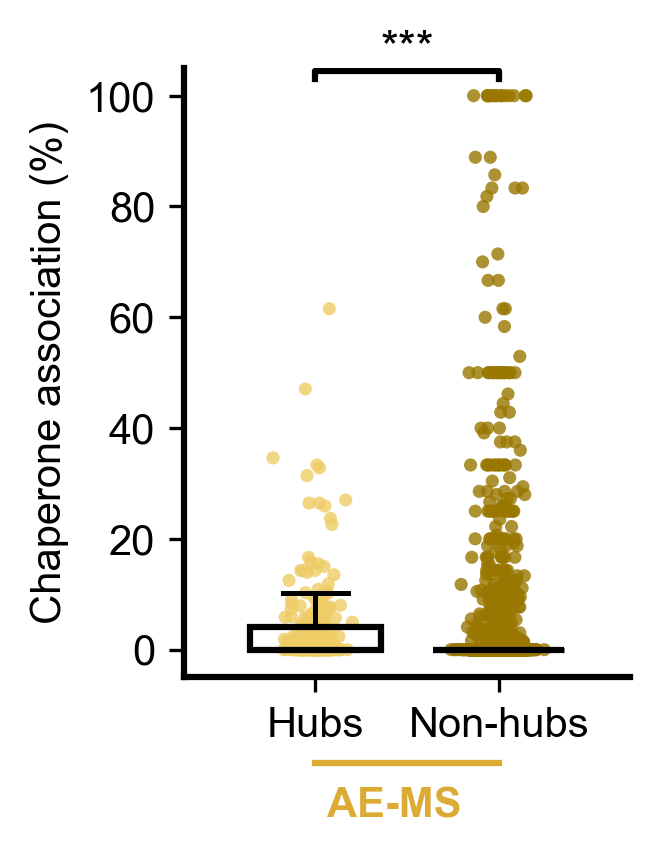

In [8]:
def add_bracket_with_text(ax, x1, x2, y, text):
    y_top = y + 1.5     
    ax.plot(
        [x1, x1, x2, x2],
        [y,  y_top, y_top, y],
        lw=1.5,
        c="black",
        zorder=4,
    )
    ax.text(
        (x1 + x2) / 2,
        y_top + 0.015,
        text,
        ha="center",
        va="bottom",
        fontsize=11,
        zorder=4,
    )
    
fig, ax = plt.subplots(figsize=(2.3, 3))

group_vals   = [hub_frac, nonhub_frac]
group_colors = [MS_COLOR_LIGHT, MS_COLOR_DARK]

# --- Scatter ---
positions    = [1, 1.7]
for pos, (vals, color) in zip(positions, zip(group_vals, group_colors)):
    x_jitter = pos + np.random.normal(0, 0.05, size=len(vals))
    ax.scatter(
        x_jitter,
        vals,
        s=10,
        alpha=0.8,
        color=color,
        edgecolor="none",
        zorder=2,
    )

# --- Boxplots ---
bp = ax.boxplot(
    group_vals,
    labels=["Hubs", "Non-hubs"],
    positions=positions,
    widths=0.5,               
    patch_artist=True,
    showfliers=False,
)

for box in bp["boxes"]:
    box.set_facecolor("none")
    box.set_edgecolor("black")
    box.set_linewidth(1.5)
    box.set_zorder(3)

for element in ["whiskers", "caps", "medians"]:
    for line in bp[element]:
        line.set_color("black")
        line.set_linewidth(1.2)
        line.set_zorder(3)
        
ax.set_ylabel("Chaperone association (%)")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.5)
ax.spines["bottom"].set_linewidth(1.5)

# --- Axes styling ---
#ax.set_ylim(-0.1, max(hub_frac.max(), nonhub_frac.max()) + 0.15)
y_min = -5                  
y_max = 105
#y_high = max(hub_frac.max(), nonhub_frac.max()) + 0.04
ax.set_ylim(y_min, y_max)

# Significance bracket slightly above the highest data point
#bracket_y = max(hub_frac.max(), nonhub_frac.max()) + 0.5   
bracket_y = 103

# Custom y-axis ticks
yticks = [0, 20, 40, 60, 80, 100]
ax.set_yticks(yticks)
#ax.set_yticklabels([f"{y:.1f}" for y in yticks], fontsize=10)
ax.set_yticklabels([f"{int(y)}" for y in yticks], fontsize=10)

# Draw bracket
add_bracket_with_text(ax, positions[0], positions[1], bracket_y, "***")

# Horizontal line
trans = ax.get_xaxis_transform()

ax.plot(
    [1.0, 1.7], [-0.14, -0.14],
    transform=trans,
    clip_on=False,
    color=MS_COLOR,
    lw=1.5,
)

ax.text(
    1.3, -0.18, "AE-MS",
    transform=trans,
    ha="center",
    va="top",
    fontsize=10,
    fontweight="bold",
    color=MS_COLOR,
)

plt.xticks(fontsize=10)
plt.tight_layout()
plt.savefig(f"{OUT_PATH}6a-1-v2.svg")
plt.show()

In [9]:
# Extract chaperone fraction for Static vs Dynamic Hubs
# Extract static and dynamic hubs
static_df  = final_df[final_df["hub_type"] == "static"].copy()
dynamic_df = final_df[final_df["hub_type"] == "dynamic"].copy()

# Clean values
static_frac = static_df["chaperone_fraction"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

dynamic_frac = dynamic_df["chaperone_fraction"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

# Groups: (label, data, color)
groups = [
    ("Hubs",     static_frac,    MS_COLOR),
    ("Non-hubs", dynamic_frac, MS_COLOR),
]

# 2. Compute bootstrapped medians + CIs
medians = []
ci_lowers = []
ci_uppers = []
labels = []
colors = []

for label, vals, color in groups:
    m, lo, hi = bootstrap_ci_median(vals, B=1_000_000, ci=95, random_state=42)
    medians.append(m)
    ci_lowers.append(lo)
    ci_uppers.append(hi)
    labels.append(label)
    colors.append(color)
    print(f"{label}: median={m:.2f}, 95% CI=({lo:.2f}, {hi:.2f}), n={len(vals)})")

medians = np.array(medians)
ci_lowers = np.array(ci_lowers)
ci_uppers = np.array(ci_uppers)

# Convert to yerr format for Matplotlib: [lower_err, upper_err]
yerr = np.vstack([medians - ci_lowers, ci_uppers - medians])

Bootstrapping medians: 100%|████████████████████████████████| 1000000/1000000 [00:12<00:00, 80393.42it/s]


Hubs: median=0.00, 95% CI=(0.00, 0.00), n=142)


Bootstrapping medians: 100%|████████████████████████████████| 1000000/1000000 [00:12<00:00, 81952.74it/s]

Non-hubs: median=0.00, 95% CI=(0.00, 1.11), n=105)


In [10]:
# MWU test — Hub+Chap vs Hub+NoChap
ms_u, ms_p = mannwhitneyu(static_frac, dynamic_frac, alternative="two-sided")

print("=== Mann–Whitney U tests on Hubs vs Non-Hubs (chaperone fraction) ===")

print("\nHub + Chaperone vs Hub + NoChaperone")
print(f"n(static)  = {len(static_frac)}, n(dynamic) = {len(dynamic_frac)}")
print(f"median(static) = {np.median(static_frac):.2f}, median(dynamic) = {np.median(dynamic_frac):.2f}")
print(f"U = {ms_u:.2f}, p = {ms_p:.4g}")

# Mean boolean (≥1 chaperone contact)
print("Static hubs median:", 
      (final_df[final_df["hub_type"] == "static"]["num_chaperone_interactions"] > 0).mean())

print("Dynamic hubs median:", 
      (final_df[final_df["hub_type"] == "dynamic"]["num_chaperone_interactions"] > 0).mean())

=== Mann–Whitney U tests on Hubs vs Non-Hubs (chaperone fraction) ===

Hub + Chaperone vs Hub + NoChaperone
n(static)  = 142, n(dynamic) = 105
median(static) = 0.00, median(dynamic) = 0.00
U = 6845.00, p = 0.2189
Static hubs median: 0.3732394366197183
Dynamic hubs median: 0.4666666666666667


/var/folders/62/56bdxfp95bl8fmn_37yc9g080000gn/T/ipykernel_34571/2062550637.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


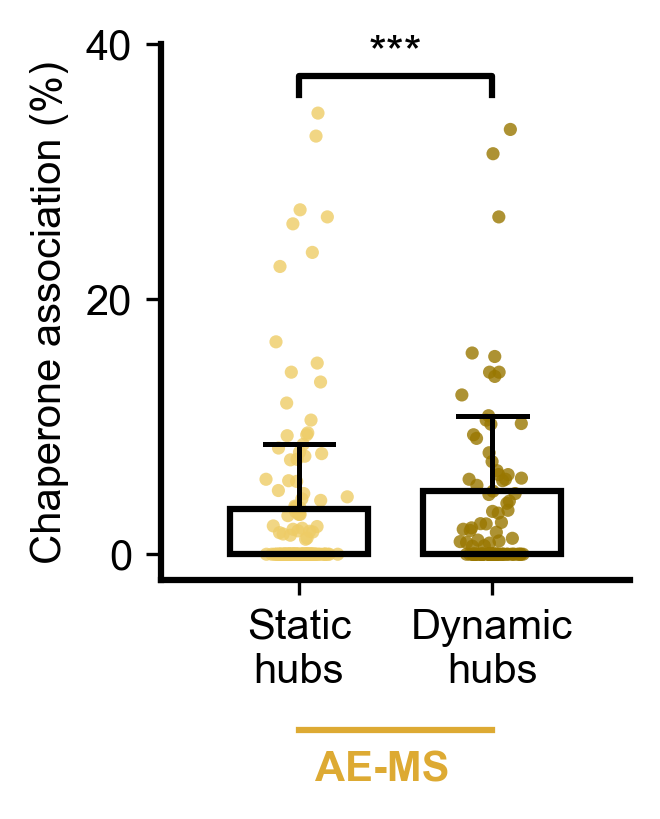

In [11]:
def add_bracket_with_text(ax, x1, x2, y, text):
    y_top = y + 1.5  
    ax.plot(
        [x1, x1, x2, x2],
        [y,  y_top, y_top, y],
        lw=1.5,
        c="black",
        zorder=4,
    )
    ax.text(
        (x1 + x2) / 2,
        y_top + 0.015,
        text,
        ha="center",
        va="bottom",
        fontsize=11,
        zorder=4,
    )
    
fig, ax = plt.subplots(figsize=(2.3, 3))

group_vals   = [static_frac, dynamic_frac]
group_colors = [MS_COLOR_LIGHT, MS_COLOR_DARK]

# Scatter points
positions    = [1, 1.7]
for pos, (vals, color) in zip(positions, zip(group_vals, group_colors)):
    x_jitter = pos + np.random.normal(0, 0.05, size=len(vals))
    ax.scatter(
        x_jitter,
        vals,
        s=10,
        alpha=0.8,
        color=color,
        edgecolor="none",
        zorder=2,
    )

# Boxplots
bp = ax.boxplot(
    group_vals,
    labels=["Static\nhubs", "Dynamic\nhubs"],
    positions=positions,
    widths=0.5,                 
    patch_artist=True,
    showfliers=False,
)

for box in bp["boxes"]:
    box.set_facecolor("none")
    box.set_edgecolor("black")
    box.set_linewidth(1.5)
    box.set_zorder(3)

for element in ["whiskers", "caps", "medians"]:
    for line in bp[element]:
        line.set_color("black")
        line.set_linewidth(1.2)
        line.set_zorder(3)

# Axis cosmetics
ax.set_ylabel("Chaperone association (%)")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.5)
ax.spines["bottom"].set_linewidth(1.5)

# --- Axes styling ---
y_min  = -2
y_max = 40
#y_high = max(static_frac.max(), dynamic_frac.max()) + 0.03
ax.set_ylim(y_min, y_max)

# Custom Y-ticks 
yticks = [0, 20, 40]
ax.set_yticks(yticks)
ax.set_yticklabels([f"{int(y)}" for y in yticks], fontsize=10)

# Significance bracket slightly above the highest data point
bracket_y = 36

# Draw bracket
add_bracket_with_text(ax, positions[0], positions[1], bracket_y, "***")

# Horizontal line
trans = ax.get_xaxis_transform()

ax.plot(
    [1.0, 1.7], [-0.28, -0.28],
    transform=trans,
    clip_on=False,
    color=MS_COLOR,
    lw=1.5,
)

ax.text(
    1.3, -0.32, "AE-MS",
    transform=trans,
    ha="center",
    va="top",
    fontsize=10,
    fontweight="bold",
    color=MS_COLOR,
)

plt.xticks(fontsize=10)
plt.tight_layout()
plt.savefig(f"{OUT_PATH}6a-2-v2.svg")
plt.show()

In [12]:
#Compute hub + chaperone groups for Ghosh–Dill ΔG
# Create a boolean for chaperone interaction
final_df["has_chaperone"] = final_df["num_chaperone_interactions"] > 0

# HUBS ONLY 
hub_df = final_df[final_df["is_hub"] == True].copy()

hub_chap     = hub_df[hub_df["has_chaperone"] == True]["Ghosh-Dill-dG"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()
hub_nochap   = hub_df[hub_df["has_chaperone"] == False]["Ghosh-Dill-dG"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

# Groups: (label, data, color)
groups = [
    ("Hub + Chaperone", hub_chap, MS_COLOR_LIGHT),
    ("Hub + No Chaperone", hub_nochap, MS_COLOR_DARK),
]

# 2. Compute bootstrapped medians + CIs
medians = []
ci_lowers = []
ci_uppers = []
labels = []
colors = []

for label, vals, color in groups:
    m, lo, hi = bootstrap_ci_median(vals, B=1_000_000, ci=95, random_state=42)
    medians.append(m)
    ci_lowers.append(lo)
    ci_uppers.append(hi)
    labels.append(label)
    colors.append(color)
    print(f"{label}: median={m:.2f}, 95% CI=({lo:.2f}, {hi:.2f}), n={len(vals)})")

medians = np.array(medians)
ci_lowers = np.array(ci_lowers)
ci_uppers = np.array(ci_uppers)

# Convert to yerr format for Matplotlib: [lower_err, upper_err]
yerr = np.vstack([medians - ci_lowers, ci_uppers - medians])

Bootstrapping medians: 100%|████████████████████████████████| 1000000/1000000 [00:12<00:00, 80673.14it/s]


Hub + Chaperone: median=-11.38, 95% CI=(-12.88, -10.38), n=102)


Bootstrapping medians: 100%|████████████████████████████████| 1000000/1000000 [00:12<00:00, 76928.60it/s]

Hub + No Chaperone: median=-11.25, 95% CI=(-12.38, -10.25), n=145)


In [13]:
# MWU test — Hub+Chap vs Hub+NoChap
ms_u, ms_p = mannwhitneyu(hub_chap, hub_nochap, alternative="two-sided")

print("=== Mann–Whitney U tests on Ghosh-Dill-dG ===")

print("\nMS Hub - Chaperone  associated vs MS Hub - Chaperone  independent")
print(f"n(chap) = {len(hub_chap)}, n(nochap) = {len(hub_nochap)}")
print(f"median(chap) = {np.median(hub_chap):.2f}, median(nochap) = {np.median(hub_nochap):.2f}")
print(f"U = {ms_u:.2f}, p = {ms_p:.4g}")

=== Mann–Whitney U tests on Ghosh-Dill-dG ===

MS Hub - Chaperone  associated vs MS Hub - Chaperone  independent
n(chap) = 102, n(nochap) = 145
median(chap) = -11.38, median(nochap) = -11.25
U = 7893.50, p = 0.3677


/var/folders/62/56bdxfp95bl8fmn_37yc9g080000gn/T/ipykernel_34571/3567445882.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


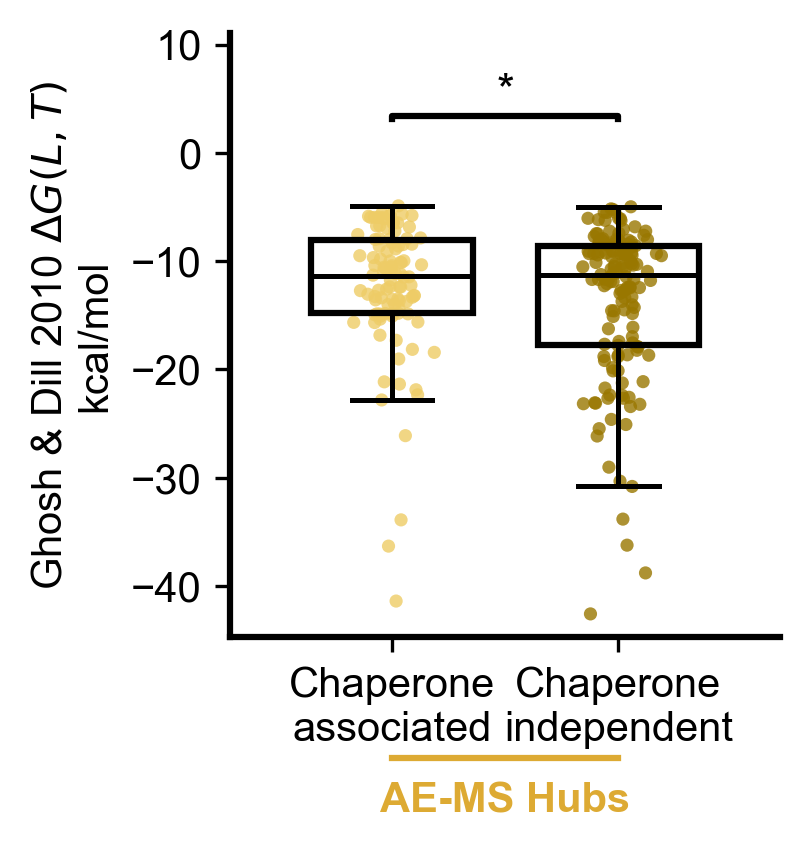

In [14]:
# Plot annotations
def add_bracket_with_text(ax, x1, x2, y, text):
    y_top = y * 1.1
    ax.plot(
        [x1, x1, x2, x2],
        [y,  y_top, y_top, y],
        lw=1.5,
        c="black",
        zorder=4,
    )
    ax.text(
        (x1 + x2) / 2,
        y_top * 1.05,
        text,
        ha="center",
        va="bottom",
        fontsize=11,
        zorder=4,
    )
    
fig, ax = plt.subplots(figsize=(2.8, 3))

group_vals   = [hub_chap, hub_nochap]
group_colors = [MS_COLOR_LIGHT, MS_COLOR_DARK]

# --- Scatter first (lower zorder) ---
positions = [1, 1.7]
for pos, (vals, color) in zip(positions, zip(group_vals, group_colors)):
    x_jitter = pos + np.random.normal(0, 0.05, size=len(vals))
    ax.scatter(
        x_jitter,
        vals,
        s=10,
        alpha=0.8,
        color=color,
        edgecolor="none",
        zorder=2,
    )

# --- Boxplots on top: outlines only, no fill, no fliers ---
bp = ax.boxplot(
    group_vals,
    labels=["Chaperone\nassociated", "Chaperone\nindependent"],
    positions=positions,
    widths=0.5,
    patch_artist=True,
    showfliers=False,
)

for box in bp["boxes"]:
    box.set_facecolor("none")
    box.set_edgecolor("black")
    box.set_linewidth(1.5)
    box.set_zorder(3)

for element in ["whiskers", "caps", "medians"]:
    for line in bp[element]:
        line.set_color("black")
        line.set_linewidth(1.2)
        line.set_zorder(3)

# --- Axes styling ---
ax.set_ylabel(r"Ghosh & Dill 2010 $ΔG(L,T)$" + "\nkcal/mol")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.5)
ax.spines["bottom"].set_linewidth(1.5)

# Set clean y-limits: from 0 down to a bit below the lowest value
y_min = min(hub_chap.min(), hub_nochap.min())
y_max = max(hub_chap.max(), hub_nochap.max())

# Significance bracket slightly above the highest data point
bracket_y = y_max + 8

# IMPORTANT: set ylim AFTER computing bracket_y
ax.set_ylim(y_min * 1.05, bracket_y + 8)

# # Draw bracket
add_bracket_with_text(ax, positions[0], positions[1], bracket_y, "N.S.")

# === Horizontal line + label EXACTLY like your boss's style ===
# Use x-axis transform so these sit below the x-axis, not in data (log) space
trans = ax.get_xaxis_transform()

# AE-MS group label under x-axis
ax.plot(
    [1.0, 1.7], [-0.20, -0.20],
    transform=trans,
    clip_on=False,
    color=MS_COLOR,
    lw=1.5,
)

ax.text(
    1.35, -0.24, "AE-MS Hubs",
    transform=trans,
    ha="center",
    va="top",
    fontsize=10,
    fontweight="bold",
    color=MS_COLOR,
)

plt.xticks(fontsize=10)
plt.tight_layout()
plt.savefig(f"{OUT_PATH}6b-1-v2.svg")
plt.show()

In [15]:
#Compute hub + chaperone groups for cagiada ΔG
# Create a boolean for chaperone interaction
final_df["has_chaperone"] = final_df["num_chaperone_interactions"] > 0

# HUBS ONLY (betweenness-based MS hubs already computed)
hub_df = final_df[final_df["is_hub"] == True].copy()

hub_chap     = hub_df[hub_df["has_chaperone"] == True]["cagiada-dG"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()
hub_nochap   = hub_df[hub_df["has_chaperone"] == False]["cagiada-dG"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

# Groups: (label, data, color)
groups = [
    ("Hub + Chaperone", hub_chap, MS_COLOR_LIGHT),
    ("Hub + No Chaperone", hub_nochap, MS_COLOR_DARK),
]

# 2. Compute bootstrapped medians + CIs
medians = []
ci_lowers = []
ci_uppers = []
labels = []
colors = []

for label, vals, color in groups:
    m, lo, hi = bootstrap_ci_median(vals, B=1_000_000, ci=95, random_state=42)
    medians.append(m)
    ci_lowers.append(lo)
    ci_uppers.append(hi)
    labels.append(label)
    colors.append(color)
    print(f"{label}: median={m:.2f}, 95% CI=({lo:.2f}, {hi:.2f}), n={len(vals)})")

medians = np.array(medians)
ci_lowers = np.array(ci_lowers)
ci_uppers = np.array(ci_uppers)

# Convert to yerr format for Matplotlib: [lower_err, upper_err]
yerr = np.vstack([medians - ci_lowers, ci_uppers - medians])

Bootstrapping medians: 100%|████████████████████████████████| 1000000/1000000 [00:12<00:00, 80298.47it/s]


Hub + Chaperone: median=-24.53, 95% CI=(-25.91, -21.11), n=102)


Bootstrapping medians: 100%|████████████████████████████████| 1000000/1000000 [00:13<00:00, 76606.00it/s]

Hub + No Chaperone: median=-19.07, 95% CI=(-22.01, -16.18), n=145)


In [16]:
# MWU test — Hub+Chap vs Hub+NoChap
ms_u, ms_p = mannwhitneyu(hub_chap, hub_nochap, alternative="two-sided")

print("=== Mann–Whitney U tests on cagiada-dG ===")

print("\nMS Hub - Chaperone  associated vs MS Hub - Chaperone  independent")
print(f"n(chap) = {len(hub_chap)}, n(nochap) = {len(hub_nochap)}")
print(f"median(chap) = {np.median(hub_chap):.2f}, median(nochap) = {np.median(hub_nochap):.2f}")
print(f"U = {ms_u:.2f}, p = {ms_p:.4g}")

=== Mann–Whitney U tests on cagiada-dG ===

MS Hub - Chaperone  associated vs MS Hub - Chaperone  independent
n(chap) = 102, n(nochap) = 145
median(chap) = -24.53, median(nochap) = -19.07
U = 6130.00, p = 0.02219


/var/folders/62/56bdxfp95bl8fmn_37yc9g080000gn/T/ipykernel_34571/1033617570.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


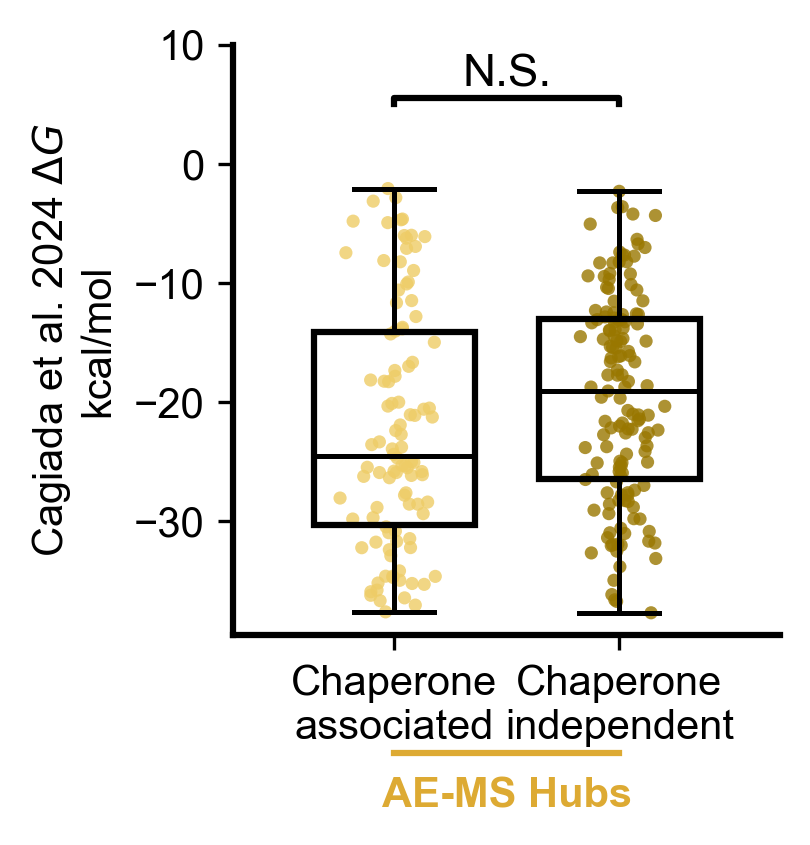

In [17]:
# Plot annotations
def add_bracket_with_text(ax, x1, x2, y, text):
    y_top = y * 1.1
    ax.plot(
        [x1, x1, x2, x2],
        [y,  y_top, y_top, y],
        lw=1.5,
        c="black",
        zorder=4,
    )
    ax.text(
        (x1 + x2) / 2,
        y_top * 1.05,
        text,
        ha="center",
        va="bottom",
        fontsize=11,
        zorder=4,
    )
    
fig, ax = plt.subplots(figsize=(2.8, 3))

group_vals   = [hub_chap, hub_nochap]
group_colors = [MS_COLOR_LIGHT, MS_COLOR_DARK]

# --- Scatter first (lower zorder) ---
positions = [1, 1.7]
for pos, (vals, color) in zip(positions, zip(group_vals, group_colors)):
    x_jitter = pos + np.random.normal(0, 0.05, size=len(vals))
    ax.scatter(
        x_jitter,
        vals,
        s=10,
        alpha=0.8,
        color=color,
        edgecolor="none",
        zorder=2,
    )

# --- Boxplots on top: outlines only, no fill, no fliers ---
bp = ax.boxplot(
    group_vals,
    labels=["Chaperone\nassociated", "Chaperone\nindependent"],
    positions=positions,
    widths=0.5,
    patch_artist=True,
    showfliers=False,
)

for box in bp["boxes"]:
    box.set_facecolor("none")
    box.set_edgecolor("black")
    box.set_linewidth(1.5)
    box.set_zorder(3)

for element in ["whiskers", "caps", "medians"]:
    for line in bp[element]:
        line.set_color("black")
        line.set_linewidth(1.2)
        line.set_zorder(3)

# --- Axes styling ---
ax.set_ylabel(r"Cagiada et al. 2024 $ΔG$" + "\nkcal/mol")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.5)
ax.spines["bottom"].set_linewidth(1.5)

# Set clean y-limits: from 0 down to a bit below the lowest value
y_min = min(hub_chap.min(), hub_nochap.min())
y_max = 10

# Significance bracket slightly above the highest data point
bracket_y = 5

# IMPORTANT: set ylim AFTER computing bracket_y
ax.set_ylim(y_min * 1.05, y_max) 

# # Draw bracket
add_bracket_with_text(ax, positions[0], positions[1], bracket_y, "*")

# === Horizontal line + label EXACTLY like your boss's style ===
# Use x-axis transform so these sit below the x-axis, not in data (log) space
trans = ax.get_xaxis_transform()

# AE-MS group label under x-axis
ax.plot(
    [1.0, 1.7], [-0.20, -0.20],
    transform=trans,
    clip_on=False,
    color=MS_COLOR,
    lw=1.5,
)

ax.text(
    1.35, -0.24, "AE-MS Hubs",
    transform=trans,
    ha="center",
    va="top",
    fontsize=10,
    fontweight="bold",
    color=MS_COLOR,
)

plt.xticks(fontsize=10)
plt.tight_layout()
plt.savefig(f"{OUT_PATH}6b-2-v2.svg")
plt.show()

In [18]:
#Compute hub + chaperone groups for Rosetta
# Create a boolean for chaperone interaction
final_df["has_chaperone"] = final_df["num_chaperone_interactions"] > 0

# HUBS ONLY (betweenness-based MS hubs already computed)
hub_df = final_df[final_df["is_hub"] == True].copy()

rosetta_hub_chap     = hub_df[hub_df["has_chaperone"] == True]["Rosetta_best_total_score"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()
rosetta_hub_nochap   = hub_df[hub_df["has_chaperone"] == False]["Rosetta_best_total_score"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

# Groups: (label, data, color)
groups = [
    ("Hub + Chaperone", rosetta_hub_chap, MS_COLOR_LIGHT),
    ("Hub + No Chaperone", rosetta_hub_nochap, MS_COLOR_DARK),
]

# 2. Compute bootstrapped medians + CIs
medians = []
ci_lowers = []
ci_uppers = []
labels = []
colors = []

for label, vals, color in groups:
    m, lo, hi = bootstrap_ci_median(vals, B=1_000_000, ci=95, random_state=42)
    medians.append(m)
    ci_lowers.append(lo)
    ci_uppers.append(hi)
    labels.append(label)
    colors.append(color)
    print(f"{label}: median={m:.2f}, 95% CI=({lo:.2f}, {hi:.2f}), n={len(vals)})")

medians = np.array(medians)
ci_lowers = np.array(ci_lowers)
ci_uppers = np.array(ci_uppers)

# Convert to yerr format for Matplotlib: [lower_err, upper_err]
yerr = np.vstack([medians - ci_lowers, ci_uppers - medians])

Bootstrapping medians: 100%|████████████████████████████████| 1000000/1000000 [00:12<00:00, 80998.86it/s]


Hub + Chaperone: median=-1286.24, 95% CI=(-1472.95, -1129.38), n=102)


Bootstrapping medians: 100%|████████████████████████████████| 1000000/1000000 [00:13<00:00, 76615.74it/s]

Hub + No Chaperone: median=-1187.23, 95% CI=(-1353.41, -989.73), n=145)


In [19]:
# MWU test — Hub+Chap vs Hub+NoChap
ms_u, ms_p = mannwhitneyu(rosetta_hub_chap, rosetta_hub_nochap, alternative="two-sided")

print("=== Mann–Whitney U tests on Rosetta_best_total_score ===")

print("\nMS Hub - Chaperone  associated vs MS Hub - Chaperone  independent")
print(f"n(chap) = {len(rosetta_hub_chap)}, n(nochap) = {len(rosetta_hub_nochap)}")
print(f"median(chap) = {np.median(rosetta_hub_chap):.2f}, median(nochap) = {np.median(rosetta_hub_nochap):.2f}")
print(f"U = {ms_u:.2f}, p = {ms_p:.4g}")

=== Mann–Whitney U tests on Rosetta_best_total_score ===

MS Hub - Chaperone  associated vs MS Hub - Chaperone  independent
n(chap) = 102, n(nochap) = 145
median(chap) = -1286.24, median(nochap) = -1187.23
U = 7475.00, p = 0.8857


In [20]:
print("Rosetta hub_chap range:", rosetta_hub_chap.min(), "to", rosetta_hub_chap.max())
print("Rosetta hub_nochap range:", rosetta_hub_nochap.min(), "to", rosetta_hub_nochap.max())


Rosetta hub_chap range: -6299.772 to 597.36
Rosetta hub_nochap range: -6482.127 to 83446.889


/var/folders/62/56bdxfp95bl8fmn_37yc9g080000gn/T/ipykernel_34571/1707497716.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


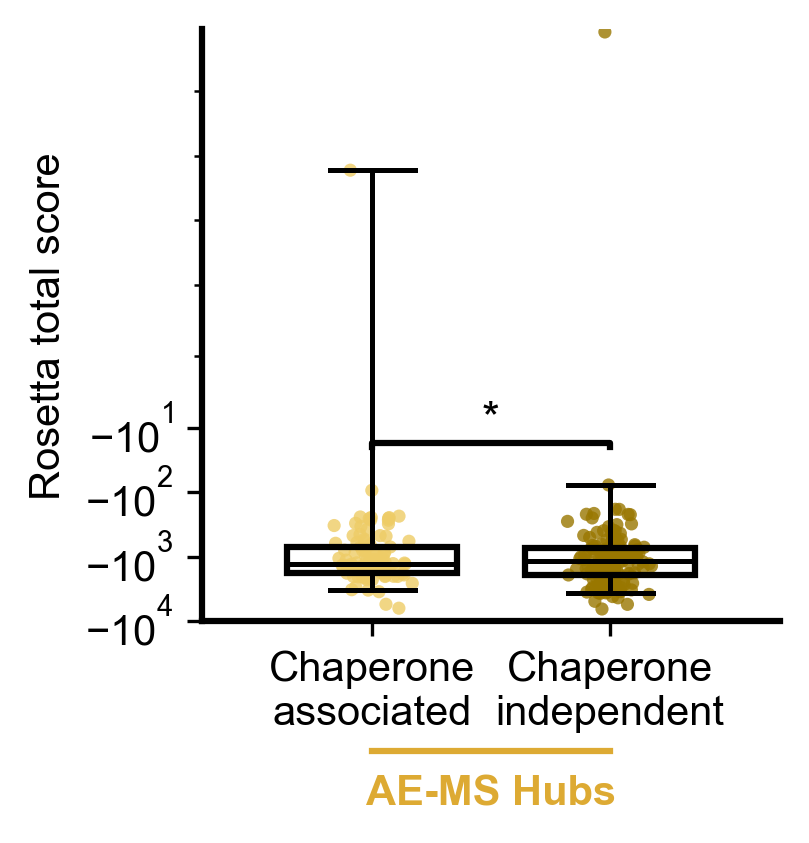

In [21]:
import matplotlib.ticker as ticker
from matplotlib.ticker import LogFormatterMathtext
# Plot annotations
def add_bracket_with_text(ax, x1, x2, y, text):
    y_top = y / 1.15
    ax.plot(
        [x1, x1, x2, x2],
        [y,  y_top, y_top, y],
        lw=1.5,
        c="black",
        zorder=4,
    )
    ax.text(
        (x1 + x2) / 2,
        y_top / 1.05,
        text,
        ha="center",
        va="bottom",
        fontsize=11,
        zorder=4,
    )
    
fig, ax = plt.subplots(figsize=(2.8, 3))

group_vals   = [rosetta_hub_chap, rosetta_hub_nochap]
group_colors = [MS_COLOR_LIGHT, MS_COLOR_DARK]

# --- Scatter first (lower zorder) ---
positions = [1, 1.7]
for pos, (vals, color) in zip(positions, zip(group_vals, group_colors)):
    x_jitter = pos + np.random.normal(0, 0.05, size=len(vals))
    ax.scatter(
        x_jitter,
        vals,
        s=10,
        alpha=0.8,
        color=color,
        edgecolor="none",
        zorder=2,
    )

# --- Boxplots on top: outlines only, no fill, no fliers ---
bp = ax.boxplot(
    group_vals,
    labels=["Chaperone\nassociated", "Chaperone\nindependent"],
    positions=positions,
    widths=0.5,
    patch_artist=True,
    showfliers=False,
)

for box in bp["boxes"]:
    box.set_facecolor("none")
    box.set_edgecolor("black")
    box.set_linewidth(1.5)
    box.set_zorder(3)

for element in ["whiskers", "caps", "medians"]:
    for line in bp[element]:
        line.set_color("black")
        line.set_linewidth(1.2)
        line.set_zorder(3)

# --- Axes styling ---
ax.set_ylabel("Rosetta total score")

# === SYMLOG SCALE ===
ax.set_yscale('symlog', linthresh=10)

# Compute y-min and y-max FIRST
y_min = min(rosetta_hub_chap.min(), rosetta_hub_nochap.min())
y_max = max(rosetta_hub_chap.max(), rosetta_hub_nochap.max())

# Expand limits slightly
ax.set_ylim(y_min * 1.1, y_max * 1.1)

tick_locs = [-1e4, -1e3, -1e2, -1e1]
ax.set_yticks(tick_locs)

ax.yaxis.set_major_formatter(LogFormatterMathtext())

# Minor ticks only on y-axis
ax.minorticks_on()
ax.xaxis.set_minor_locator(ticker.NullLocator())

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.5)
ax.spines["bottom"].set_linewidth(1.5)


# Place significance bracket at a fixed, nice height just above 0
bracket_y = -20  # you can adjust: -1, -3, -5 depending on taste
add_bracket_with_text(ax, positions[0], positions[1], bracket_y, "N.S.")

# === Horizontal line + label EXACTLY like your boss's style ===
# Use x-axis transform so these sit below the x-axis, not in data (log) space
trans = ax.get_xaxis_transform()

# AE-MS group label under x-axis
ax.plot(
    [1.0, 1.7], [-0.22, -0.22],
    transform=trans,
    clip_on=False,
    color=MS_COLOR,
    lw=1.5,
)

ax.text(
    1.35, -0.26, "AE-MS Hubs",
    transform=trans,
    ha="center",
    va="top",
    fontsize=10,
    fontweight="bold",
    color=MS_COLOR,
)

plt.xticks(fontsize=10)
plt.tight_layout()
plt.savefig(f"{OUT_PATH}6b-3-v2.svg")
plt.show()

In [22]:
#Compute hub + chaperone groups for Meltome melting point
# Create a boolean for chaperone interaction
final_df["has_chaperone"] = final_df["num_chaperone_interactions"] > 0

# HUBS ONLY (betweenness-based MS hubs already computed)
hub_df = final_df[final_df["is_hub"] == True].copy()

# Clean Ghosh–Dill values
hub_df["meltome-melting-point"] = hub_df[hub_df['meltome-fit-R2'] > 0.9]["meltome-melting-point"].replace([np.inf, -np.inf], np.nan).dropna()

hub_chap     = hub_df[hub_df["has_chaperone"] == True]["meltome-melting-point"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()
hub_nochap   = hub_df[hub_df["has_chaperone"] == False]["meltome-melting-point"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

# Groups: (label, data, color)
groups = [
    ("Hub + Chaperone", hub_chap, MS_COLOR_LIGHT),
    ("Hub + No Chaperone", hub_nochap, MS_COLOR_DARK),
]

# 2. Compute bootstrapped medians + CIs
medians = []
ci_lowers = []
ci_uppers = []
labels = []
colors = []

for label, vals, color in groups:
    m, lo, hi = bootstrap_ci_median(vals, B=1_000_000, ci=95, random_state=42)
    medians.append(m)
    ci_lowers.append(lo)
    ci_uppers.append(hi)
    labels.append(label)
    colors.append(color)
    print(f"{label}: median={m:.2f}, 95% CI=({lo:.2f}, {hi:.2f}), n={len(vals)})")

medians = np.array(medians)
ci_lowers = np.array(ci_lowers)
ci_uppers = np.array(ci_uppers)

# Convert to yerr format for Matplotlib: [lower_err, upper_err]
yerr = np.vstack([medians - ci_lowers, ci_uppers - medians])

Bootstrapping medians: 100%|████████████████████████████████| 1000000/1000000 [00:12<00:00, 81441.57it/s]


Hub + Chaperone: median=48.71, 95% CI=(47.54, 49.54), n=84)


Bootstrapping medians: 100%|████████████████████████████████| 1000000/1000000 [00:12<00:00, 81099.27it/s]

Hub + No Chaperone: median=48.34, 95% CI=(47.24, 49.05), n=93)


In [23]:
# MWU test — Hub+Chap vs Hub+NoChap
ms_u, ms_p = mannwhitneyu(hub_chap, hub_nochap, alternative="two-sided")

print("=== Mann–Whitney U tests on meltome-melting-point ===")

print("\nMS Hub - Chaperone  associated vs MS Hub - Chaperone  independent")
print(f"n(chap) = {len(hub_chap)}, n(nochap) = {len(hub_nochap)}")
print(f"median(chap) = {np.median(hub_chap):.2f}, median(nochap) = {np.median(hub_nochap):.2f}")
print(f"U = {ms_u:.2f}, p = {ms_p:.4g}")

=== Mann–Whitney U tests on meltome-melting-point ===

MS Hub - Chaperone  associated vs MS Hub - Chaperone  independent
n(chap) = 84, n(nochap) = 93
median(chap) = 48.71, median(nochap) = 48.34
U = 4063.00, p = 0.6457


/var/folders/62/56bdxfp95bl8fmn_37yc9g080000gn/T/ipykernel_34571/2615345645.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


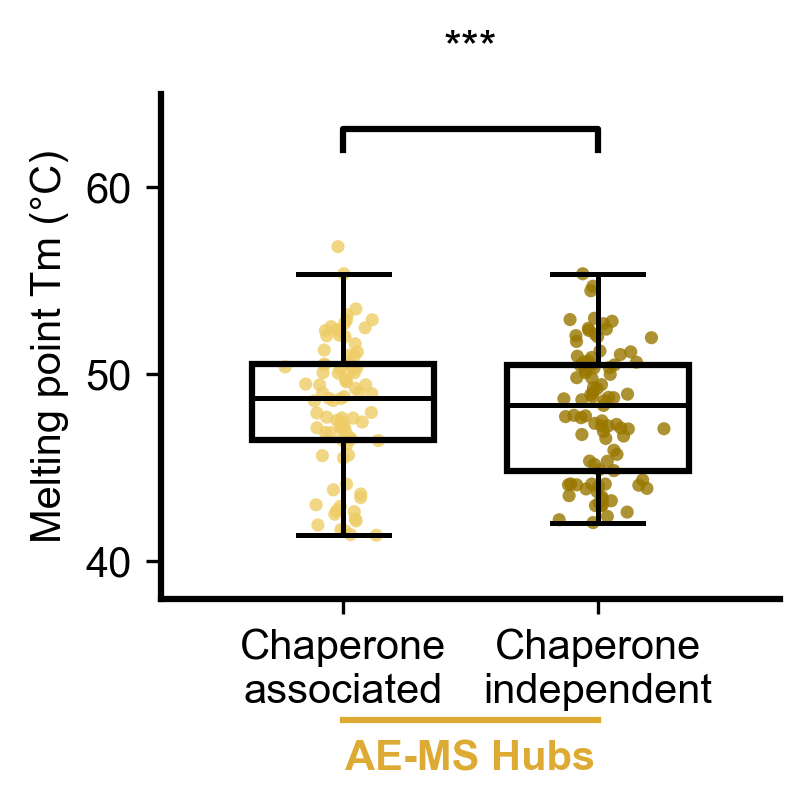

In [24]:
# Plot annotations
def add_bracket_with_text(ax, x1, x2, y, text):
    y_top = y + 1.1
    ax.plot(
        [x1, x1, x2, x2],
        [y,  y_top, y_top, y],
        lw=1.5,
        c="black",
        zorder=4,
    )
    ax.text(
        (x1 + x2) / 2,
        y_top * 1.05,
        text,
        ha="center",
        va="bottom",
        fontsize=11,
        zorder=4,
    )
    
fig, ax = plt.subplots(figsize=(2.8, 3))

group_vals   = [hub_chap, hub_nochap]
group_colors = [MS_COLOR_LIGHT, MS_COLOR_DARK]

# --- Scatter first (lower zorder) ---
positions = [1, 1.7]
for pos, (vals, color) in zip(positions, zip(group_vals, group_colors)):
    x_jitter = pos + np.random.normal(0, 0.05, size=len(vals))
    ax.scatter(
        x_jitter,
        vals,
        s=10,
        alpha=0.8,
        color=color,
        edgecolor="none",
        zorder=2,
    )

# --- Boxplots on top: outlines only, no fill, no fliers ---
bp = ax.boxplot(
    group_vals,
    labels=["Chaperone\nassociated", "Chaperone\nindependent"],
    positions=positions,
    widths=0.5,
    patch_artist=True,
    showfliers=False,
)

for box in bp["boxes"]:
    box.set_facecolor("none")
    box.set_edgecolor("black")
    box.set_linewidth(1.5)
    box.set_zorder(3)

for element in ["whiskers", "caps", "medians"]:
    for line in bp[element]:
        line.set_color("black")
        line.set_linewidth(1.2)
        line.set_zorder(3)

# --- Axes styling ---
ax.set_ylabel("Melting point Tm (°C)")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.5)
ax.spines["bottom"].set_linewidth(1.5)

# Set clean y-limits: from 0 down to a bit below the lowest value
y_min = 35     # a little below the real minimum
y_max = 60     # enough headroom for the bracket
ax.set_ylim(y_min, y_max)
ax.set_yticks([40, 50, 60])          # ← forces exactly these ticks
ax.set_yticklabels([40, 50, 60])
#y_min = min(hub_chap.min(), hub_nochap.min())
#y_max = max(hub_chap.max(), hub_nochap.max())

# Significance bracket slightly above the highest data point
bracket_y = 62

# IMPORTANT: set ylim AFTER computing bracket_y
#ax.set_ylim(y_min * 1.05, bracket_y + 8)
ax.set_ylim(38, 65) 

# # Draw bracket
add_bracket_with_text(ax, positions[0], positions[1], bracket_y, "N.S.")

# === Horizontal line + label EXACTLY like your boss's style ===
# Use x-axis transform so these sit below the x-axis, not in data (log) space
trans = ax.get_xaxis_transform()

# AE-MS group label under x-axis
ax.plot(
    [1.0, 1.7], [-0.24, -0.24],
    transform=trans,
    clip_on=False,
    color=MS_COLOR,
    lw=1.5,
)

ax.text(
    1.35, -0.28, "AE-MS Hubs",
    transform=trans,
    ha="center",
    va="top",
    fontsize=10,
    fontweight="bold",
    color=MS_COLOR,
)

plt.xticks(fontsize=10)
plt.tight_layout()
plt.savefig(f"{OUT_PATH}6b-4-v2.svg")
plt.show()

In [25]:
#Compute hub + chaperone groups 
# Create a boolean for chaperone interaction
final_df["has_chaperone"] = final_df["num_chaperone_interactions"] > 0

# HUBS ONLY (betweenness-based MS hubs already computed)
hub_df = final_df[final_df["is_hub"] == True].copy()

halflife_hub_chap     = hub_df[hub_df["has_chaperone"] == True]["Villen_halflife_min"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()
halflife_hub_nochap   = hub_df[hub_df["has_chaperone"] == False]["Villen_halflife_min"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

# Groups: (label, data, color)
groups = [
    ("Hub + Chaperone", halflife_hub_chap, MS_COLOR_LIGHT),
    ("Hub + No Chaperone", halflife_hub_nochap, MS_COLOR_DARK),
]

# 2. Compute bootstrapped medians + CIs
medians = []
ci_lowers = []
ci_uppers = []
labels = []
colors = []

for label, vals, color in groups:
    m, lo, hi = bootstrap_ci_median(vals, B=1_000_000, ci=95, random_state=42)
    medians.append(m)
    ci_lowers.append(lo)
    ci_uppers.append(hi)
    labels.append(label)
    colors.append(color)
    print(f"{label}: median={m:.2f}, 95% CI=({lo:.2f}, {hi:.2f}), n={len(vals)})")

medians = np.array(medians)
ci_lowers = np.array(ci_lowers)
ci_uppers = np.array(ci_uppers)

# Convert to yerr format for Matplotlib: [lower_err, upper_err]
yerr = np.vstack([medians - ci_lowers, ci_uppers - medians])

Bootstrapping medians: 100%|████████████████████████████████| 1000000/1000000 [00:12<00:00, 81147.93it/s]


Hub + Chaperone: median=124.80, 95% CI=(109.20, 151.20), n=89)


Bootstrapping medians: 100%|████████████████████████████████| 1000000/1000000 [00:12<00:00, 79474.27it/s]

Hub + No Chaperone: median=127.20, 95% CI=(111.60, 141.00), n=118)


In [26]:
# MWU test — Hub+Chap vs Hub+NoChap
ms_u, ms_p = mannwhitneyu(halflife_hub_chap, halflife_hub_nochap, alternative="two-sided")

print("=== Mann–Whitney U tests on Villen_halflife_min ===")

print("\nMS Hub - Chaperone  associated vs MS Hub - Chaperone  independent")
print(f"n(chap) = {len(halflife_hub_chap)}, n(nochap) = {len(halflife_hub_nochap)}")
print(f"median(chap) = {np.median(halflife_hub_chap):.2f}, median(nochap) = {np.median(halflife_hub_nochap):.2f}")
print(f"U = {ms_u:.2f}, p = {ms_p:.4g}")

=== Mann–Whitney U tests on Villen_halflife_min ===

MS Hub - Chaperone  associated vs MS Hub - Chaperone  independent
n(chap) = 89, n(nochap) = 118
median(chap) = 124.80, median(nochap) = 127.20
U = 5938.00, p = 0.1076


/var/folders/62/56bdxfp95bl8fmn_37yc9g080000gn/T/ipykernel_34571/3469162414.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


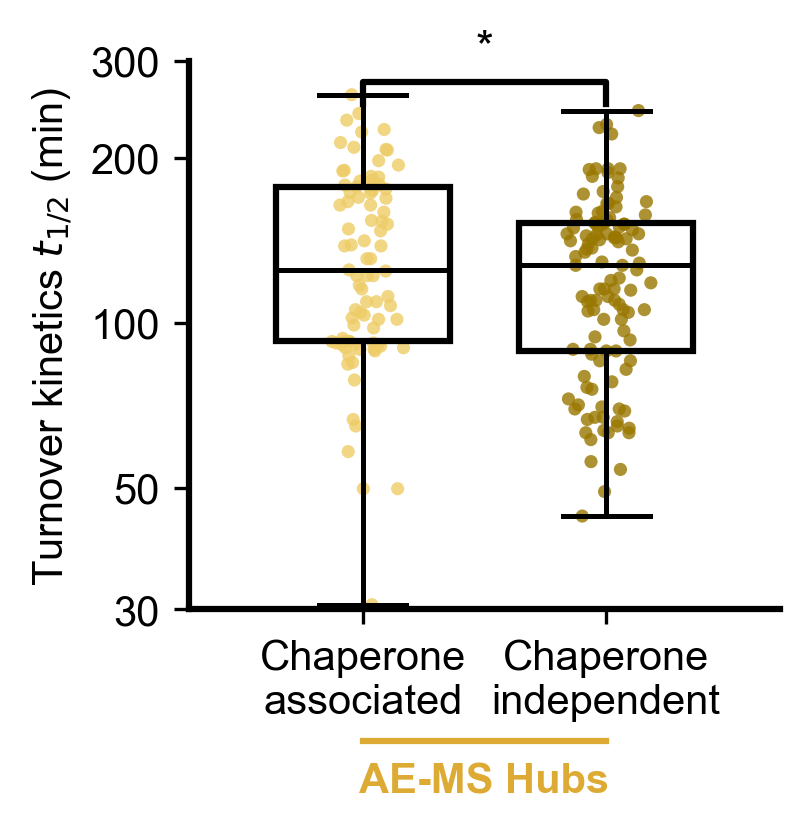

In [27]:
# Plot annotations
def add_bracket_with_text(ax, x1, x2, y, text):
    y_top = y * 1.1
    ax.plot(
        [x1, x1, x2, x2],
        [y,  y_top, y_top, y],
        lw=1.5,
        c="black",
        zorder=4,
    )
    ax.text(
        (x1 + x2) / 2,
        y_top * 1.05,
        text,
        ha="center",
        va="bottom",
        fontsize=11,
        zorder=4,
    )
    
fig, ax = plt.subplots(figsize=(2.8, 3))

group_vals   = [halflife_hub_chap, halflife_hub_nochap]
group_colors = [MS_COLOR_LIGHT, MS_COLOR_DARK]

# --- Scatter first (lower zorder) ---
positions = [1, 1.7]
for pos, (vals, color) in zip(positions, zip(group_vals, group_colors)):
    x_jitter = pos + np.random.normal(0, 0.05, size=len(vals))
    ax.scatter(
        x_jitter,
        vals,
        s=10,
        alpha=0.8,
        color=color,
        edgecolor="none",
        zorder=2,
    )

# --- Boxplots on top: outlines only, no fill, no fliers ---
bp = ax.boxplot(
    group_vals,
    labels=["Chaperone\nassociated", "Chaperone\nindependent"],
    positions=positions,
    widths=0.5,
    patch_artist=True,
    showfliers=False,
)

for box in bp["boxes"]:
    box.set_facecolor("none")
    box.set_edgecolor("black")
    box.set_linewidth(1.5)
    box.set_zorder(3)

for element in ["whiskers", "caps", "medians"]:
    for line in bp[element]:
        line.set_color("black")
        line.set_linewidth(1.2)
        line.set_zorder(3)
        
ax.set_yscale("log")
# --- Axes styling ---
ax.set_ylabel("Turnover kinetics $t_{1/2}$ (min)")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.5)
ax.spines["bottom"].set_linewidth(1.5)

# Choose clean log ticks f
yticks = [30, 50, 100, 200, 300]
ax.set_yticks(yticks)
ax.get_yaxis().set_major_formatter(ticker.ScalarFormatter())
ax.yaxis.set_minor_locator(ticker.NullLocator())

# Set clean y-limits: from 0 down to a bit below the lowest value
y_min = min(halflife_hub_chap.min(), halflife_hub_nochap.min())
y_max = max(halflife_hub_chap.max(), halflife_hub_nochap.max())

# Significance bracket slightly above the highest data point
bracket_y = 250

# IMPORTANT: set ylim AFTER computing bracket_y
ax.set_ylim(30, 300)

# # Draw bracket
add_bracket_with_text(ax, positions[0], positions[1], bracket_y, "N.S.")

# === Horizontal line + label EXACTLY like your boss's style ===
# Use x-axis transform so these sit below the x-axis, not in data (log) space
trans = ax.get_xaxis_transform()

# AE-MS group label under x-axis
ax.plot(
    [1.0, 1.7], [-0.24, -0.24],
    transform=trans,
    clip_on=False,
    color=MS_COLOR,
    lw=1.5,
)

ax.text(
    1.35, -0.28, "AE-MS Hubs",
    transform=trans,
    ha="center",
    va="top",
    fontsize=10,
    fontweight="bold",
    color=MS_COLOR,
)

plt.xticks(fontsize=10)
plt.tight_layout()
plt.savefig(f"{OUT_PATH}6b-5-v2.svg")
plt.show()

In [28]:
# Prepare Static/Dynamic + Chaperone Groups for Turnover t1/2

# Hubs only
hub_df = final_df[final_df["is_hub"] == True].copy()

# Static vs Dynamic subsets
static_df  = hub_df[hub_df["hub_type"] == "static"].copy()
dynamic_df = hub_df[hub_df["hub_type"] == "dynamic"].copy()

# Clean values (replace inf, nan)
static_chap = static_df[static_df["has_chaperone"] == True]["Villen_halflife_min"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

static_nochap = static_df[static_df["has_chaperone"] == False]["Villen_halflife_min"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

dynamic_chap = dynamic_df[dynamic_df["has_chaperone"] == True]["Villen_halflife_min"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

dynamic_nochap = dynamic_df[dynamic_df["has_chaperone"] == False]["Villen_halflife_min"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

# Print counts 
groups_step3 = [
    ("Static + Chap",    static_chap,    MS_COLOR_LIGHT),
    ("Static + NoChap",  static_nochap,  MS_COLOR_DARK),
    ("Dynamic + Chap",   dynamic_chap,   MS_COLOR_LIGHT),
    ("Dynamic + NoChap", dynamic_nochap, MS_COLOR_DARK),
]

print("=== Protein counts in betweenness Hubs (MS) ===")
for label, vals, _ in groups_step3:
    print(f"{label:18}: n = {len(vals)}")


# ================================================================
# Bootstrapped medians (boss-style)
# ================================================================
print("\n=== Bootstrapped median half-life (95% CI) ===")
medians, ci_lowers, ci_uppers = [], [], []

for label, vals, color in groups_step3:
    m, lo, hi = bootstrap_ci_median(vals, B=1_000_000, random_state=42)
    medians.append(m)
    ci_lowers.append(lo)
    ci_uppers.append(hi)
    print(f"{label:18}: median = {m:.1f} min, 95% CI = ({lo:.1f}, {hi:.1f})")

=== Protein counts in betweenness Hubs (MS) ===
Static + Chap     : n = 45
Static + NoChap   : n = 75
Dynamic + Chap    : n = 44
Dynamic + NoChap  : n = 43

=== Bootstrapped median half-life (95% CI) ===


Bootstrapping medians: 100%|████████████████████████████████| 1000000/1000000 [00:14<00:00, 70708.68it/s]


Static + Chap     : median = 130.8 min, 95% CI = (109.2, 148.2)


Bootstrapping medians: 100%|████████████████████████████████| 1000000/1000000 [00:12<00:00, 80311.65it/s]


Static + NoChap   : median = 132.0 min, 95% CI = (115.2, 142.2)


Bootstrapping medians: 100%|████████████████████████████████| 1000000/1000000 [00:14<00:00, 70226.90it/s]


Dynamic + Chap    : median = 121.8 min, 95% CI = (97.8, 175.2)


Bootstrapping medians: 100%|████████████████████████████████| 1000000/1000000 [00:13<00:00, 71458.31it/s]


Dynamic + NoChap  : median = 105.6 min, 95% CI = (85.2, 144.0)


In [29]:
# Mann–Whitney U tests
print("\n=== Mann–Whitney U tests (Static/Dynamic × Chaperone) ===")

def mwu_print(x, y, label):
    u, p = mannwhitneyu(x, y, alternative="two-sided")
    stars = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "N.S."
    print(f"{label:30}: U={u:.1f}, p={p:.3g}, significance={stars}")
    return stars

# 1. Within Static: Chaperone vs NoChaperone
stars_static = mwu_print(static_chap, static_nochap,
                         "Static+Chap vs Static+NoChap")

# 2. Within Dynamic: Chaperone vs NoChaperone
stars_dynamic = mwu_print(dynamic_chap, dynamic_nochap,
                          "Dynamic+Chap vs Dynamic+NoChap")

# 3. Between types (Chaperone only)
stars_chap = mwu_print(static_chap, dynamic_chap,
                       "Static+Chap vs Dynamic+Chap")

# 4. Between types (NoChaperone only)
stars_nochap = mwu_print(static_nochap, dynamic_nochap,
                         "Static+NoChap vs Dynamic+NoChap")


=== Mann–Whitney U tests (Static/Dynamic × Chaperone) ===
Static+Chap vs Static+NoChap  : U=1792.0, p=0.573, significance=N.S.
Dynamic+Chap vs Dynamic+NoChap: U=1169.5, p=0.0583, significance=N.S.
Static+Chap vs Dynamic+Chap   : U=939.0, p=0.679, significance=N.S.
Static+NoChap vs Dynamic+NoChap: U=1801.0, p=0.293, significance=N.S.


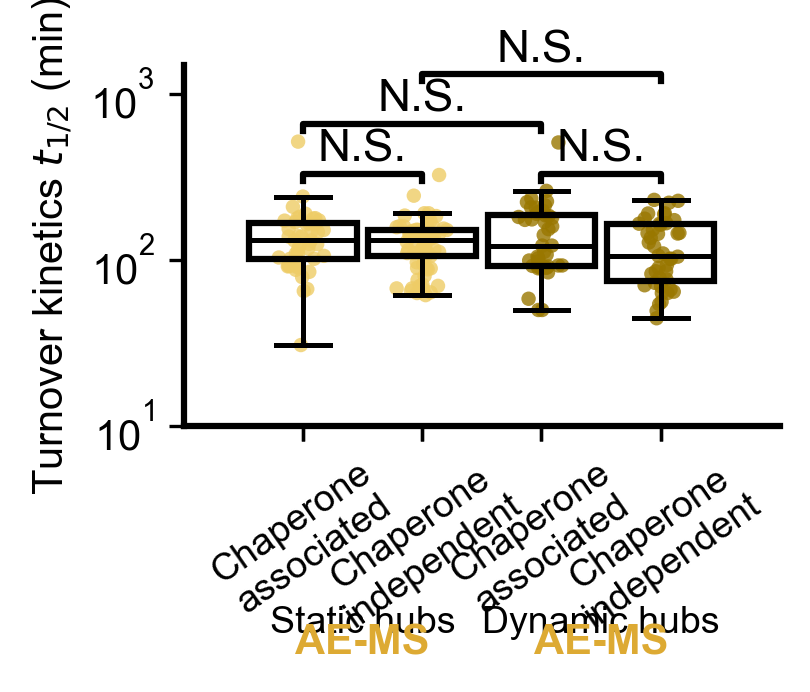

In [30]:
fig, ax = plt.subplots(figsize=(2.8, 3))

positions     = [1.0, 1.5, 2.0, 2.5]
group_data   = [static_chap, static_nochap, dynamic_chap, dynamic_nochap]
group_colors = [MS_COLOR_LIGHT, MS_COLOR_LIGHT, MS_COLOR_DARK, MS_COLOR_DARK]

group_labels = [
    "Chaperone\nassociated",
    "Chaperone\nindependent",
    "Chaperone\nassociated",
    "Chaperone\nindependent"
]

ax.set_xticks(positions)
ax.set_xticklabels(
    ["Chaperone\nassociated",
     "Chaperone\nindependent",
     "Chaperone\nassociated",
     "Chaperone\nindependent"],
    rotation=35,
    ha='center',
    fontsize=9
)

# Scatter (jitter)
for pos, (vals, color) in zip(positions, zip(group_data, group_colors)):
    x_jitter = pos + np.random.normal(0, 0.04, size=len(vals))
    ax.scatter(
        x_jitter, vals,
        s=12, alpha=0.8,
        color=color,
        edgecolor="none",
        zorder=2
    )

# Boxplots
bp = ax.boxplot(
    group_data,
    tick_labels=group_labels,
    positions=positions,
    widths=0.45,
    patch_artist=True,
    showfliers=False
)

for box, color in zip(bp["boxes"], group_colors):
    box.set_facecolor("none")
    box.set_edgecolor("black")
    box.set_linewidth(1.5)
    box.set_zorder(3)

for element in ["whiskers", "caps", "medians"]:
    for line in bp[element]:
        line.set_color("black")
        line.set_linewidth(1.2)
        line.set_zorder(3)

# Styling
ax.set_yscale("log")
ax.set_ylim(10, 1500)
ax.minorticks_off()
ax.set_ylabel(r'Turnover kinetics $t_{1/2}$ (min)')

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.5)
ax.spines["bottom"].set_linewidth(1.5)

# Significance brackets — for the two comparisons
# 1. Static + Chap vs Static + NoChap    (1.0 vs 1.5)
add_bracket_with_text(ax, 1.0, 1.5, 300, stars_static)

# 2. Dynamic + Chap vs Dynamic + NoChap  (2.0 vs 2.5)
add_bracket_with_text(ax, 2.0, 2.5, 300, stars_dynamic)

# 3. Static + Chap vs Dynamic + Chap     (1.0 vs 2.0)
add_bracket_with_text(ax, 1.0, 2.0, 600, stars_chap)

# 4. Static + NoChap vs Dynamic + NoChap (1.5 vs 2.5)
add_bracket_with_text(ax, 1.5, 2.5, 1200, stars_nochap)

# Bottom AE-MS label
trans = ax.get_xaxis_transform()
# STATIC hubs label
ax.text(1.25, -0.50, "Static hubs",
        transform=trans, ha="center",
        fontsize=9, va="top")

ax.text(1.25, -0.55, "AE-MS",
        transform=trans, ha="center",
        fontsize=10, fontweight="bold",
        va="top", color=MS_COLOR)

# dynamic
ax.text(2.25, -0.50, "Dynamic hubs",
        transform=trans, ha="center",
        fontsize=9, va="top")

ax.text(2.25, -0.55, "AE-MS",
        transform=trans, ha="center",
        fontsize=10, fontweight="bold",
        va="top", color=MS_COLOR)

plt.tight_layout()
plt.savefig(f"{OUT_PATH}6c-5-v2.svg", dpi=400, bbox_inches='tight')
plt.show()

In [31]:
# Prepare Static/Dynamic + Chaperone Groups for Turnover t1/2

# Hubs only
hub_df = final_df[final_df["is_hub"] == True].copy()

# Filter Meltome to high-confidence fits
hub_df = hub_df[hub_df["meltome-fit-R2"] > 0.9].copy()

# Convert meltome to numeric and clean
hub_df["meltome-melting-point"] = pd.to_numeric(
    hub_df["meltome-melting-point"], errors="coerce"
)

# Static vs Dynamic subsets
static_df  = hub_df[hub_df["hub_type"] == "static"].copy()
dynamic_df = hub_df[hub_df["hub_type"] == "dynamic"].copy()

# Clean values (replace inf, nan)
static_chap = static_df[static_df["has_chaperone"] == True]["meltome-melting-point"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

static_nochap = static_df[static_df["has_chaperone"] == False]["meltome-melting-point"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

dynamic_chap = dynamic_df[dynamic_df["has_chaperone"] == True]["meltome-melting-point"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

dynamic_nochap = dynamic_df[dynamic_df["has_chaperone"] == False]["meltome-melting-point"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

# Print counts 
groups_step3 = [
    ("Static + Chap",    static_chap,    MS_COLOR_LIGHT),
    ("Static + NoChap",  static_nochap,  MS_COLOR_DARK),
    ("Dynamic + Chap",   dynamic_chap,   MS_COLOR_LIGHT),
    ("Dynamic + NoChap", dynamic_nochap, MS_COLOR_DARK),
]

print("=== Protein counts in betweenness Hubs (MS) ===")
for label, vals, _ in groups_step3:
    print(f"{label:18}: n = {len(vals)}")


# ================================================================
# Bootstrapped medians (boss-style)
# ================================================================
print("\n=== Bootstrapped median meltome-melting-point (95% CI) ===")
medians, ci_lowers, ci_uppers = [], [], []

for label, vals, color in groups_step3:
    m, lo, hi = bootstrap_ci_median(vals, B=1_000_000, random_state=42)
    medians.append(m)
    ci_lowers.append(lo)
    ci_uppers.append(hi)
    print(f"{label:18}: median = {m:.1f} °C, 95% CI = ({lo:.1f}, {hi:.1f})")

=== Protein counts in betweenness Hubs (MS) ===
Static + Chap     : n = 41
Static + NoChap   : n = 56
Dynamic + Chap    : n = 43
Dynamic + NoChap  : n = 37

=== Bootstrapped median meltome-melting-point (95% CI) ===


Bootstrapping medians: 100%|████████████████████████████████| 1000000/1000000 [00:14<00:00, 69735.97it/s]


Static + Chap     : median = 48.6 °C, 95% CI = (47.5, 49.5)


Bootstrapping medians: 100%|████████████████████████████████| 1000000/1000000 [00:13<00:00, 71865.02it/s]


Static + NoChap   : median = 47.8 °C, 95% CI = (47.0, 49.1)


Bootstrapping medians: 100%|████████████████████████████████| 1000000/1000000 [00:14<00:00, 70868.62it/s]


Dynamic + Chap    : median = 48.7 °C, 95% CI = (47.1, 50.5)


Bootstrapping medians: 100%|████████████████████████████████| 1000000/1000000 [00:14<00:00, 70039.79it/s]

Dynamic + NoChap  : median = 48.7 °C, 95% CI = (46.8, 51.2)


In [32]:
# Mann–Whitney U tests
print("\n=== Mann–Whitney U tests (Static/Dynamic × Chaperone) ===")

def mwu_print(x, y, label):
    u, p = mannwhitneyu(x, y, alternative="two-sided")
    stars = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "N.S."
    print(f"{label:30}: U={u:.1f}, p={p:.3g}, significance={stars}")
    return stars

# 1. Within Static: Chaperone vs NoChaperone
stars_static = mwu_print(static_chap, static_nochap,
                         "Static+Chap vs Static+NoChap")

# 2. Within Dynamic: Chaperone vs NoChaperone
stars_dynamic = mwu_print(dynamic_chap, dynamic_nochap,
                          "Dynamic+Chap vs Dynamic+NoChap")

# 3. Between types (Chaperone only)
stars_chap = mwu_print(static_chap, dynamic_chap,
                       "Static+Chap vs Dynamic+Chap")

# 4. Between types (NoChaperone only)
stars_nochap = mwu_print(static_nochap, dynamic_nochap,
                         "Static+NoChap vs Dynamic+NoChap")


=== Mann–Whitney U tests (Static/Dynamic × Chaperone) ===
Static+Chap vs Static+NoChap  : U=1246.5, p=0.474, significance=N.S.
Dynamic+Chap vs Dynamic+NoChap: U=760.0, p=0.736, significance=N.S.
Static+Chap vs Dynamic+Chap   : U=835.5, p=0.684, significance=N.S.
Static+NoChap vs Dynamic+NoChap: U=893.0, p=0.263, significance=N.S.


In [33]:
# Prepare Static/Dynamic + Chaperone Groups

# Hubs only
hub_df = final_df[final_df["is_hub"] == True].copy()

# Clean Rosetta score column ONCE
hub_df["Rosetta_best_total_score"] = (
    pd.to_numeric(hub_df["Rosetta_best_total_score"], errors='coerce')
      .replace([np.inf, -np.inf], np.nan)
)

# Static vs Dynamic subsets
static_df  = hub_df[hub_df["hub_type"] == "static"].copy()
dynamic_df = hub_df[hub_df["hub_type"] == "dynamic"].copy()

# Clean values (replace inf, nan)
static_chap = static_df[static_df["has_chaperone"] == True]["Rosetta_best_total_score"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

static_nochap = static_df[static_df["has_chaperone"] == False]["Rosetta_best_total_score"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

dynamic_chap = dynamic_df[dynamic_df["has_chaperone"] == True]["Rosetta_best_total_score"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

dynamic_nochap = dynamic_df[dynamic_df["has_chaperone"] == False]["Rosetta_best_total_score"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

# Print counts 
groups_step3 = [
    ("Static + Chap",    static_chap,    MS_COLOR_LIGHT),
    ("Static + NoChap",  static_nochap,  MS_COLOR_DARK),
    ("Dynamic + Chap",   dynamic_chap,   MS_COLOR_LIGHT),
    ("Dynamic + NoChap", dynamic_nochap, MS_COLOR_DARK),
]

print("=== Protein counts in betweenness Hubs (MS) ===")
for label, vals, _ in groups_step3:
    print(f"{label:18}: n = {len(vals)}")


# ================================================================
# Bootstrapped medians (boss-style)
# ================================================================
print("\n=== Bootstrapped median Rosetta_best_total_score (95% CI) ===")
medians, ci_lowers, ci_uppers = [], [], []

for label, vals, color in groups_step3:
    m, lo, hi = bootstrap_ci_median(vals, B=1_000_000, random_state=42)
    medians.append(m)
    ci_lowers.append(lo)
    ci_uppers.append(hi)
    print(f"{label:18}: median = {m:.1f} kcal/mol, 95% CI = ({lo:.1f}, {hi:.1f})")

=== Protein counts in betweenness Hubs (MS) ===
Static + Chap     : n = 53
Static + NoChap   : n = 89
Dynamic + Chap    : n = 49
Dynamic + NoChap  : n = 56

=== Bootstrapped median Rosetta_best_total_score (95% CI) ===


Bootstrapping medians: 100%|████████████████████████████████| 1000000/1000000 [00:14<00:00, 70848.09it/s]


Static + Chap     : median = -1292.0 kcal/mol, 95% CI = (-1583.7, -1125.8)


Bootstrapping medians: 100%|████████████████████████████████| 1000000/1000000 [00:12<00:00, 82052.17it/s]


Static + NoChap   : median = -1206.3 kcal/mol, 95% CI = (-1420.7, -949.1)


Bootstrapping medians: 100%|████████████████████████████████| 1000000/1000000 [00:14<00:00, 70871.23it/s]


Dynamic + Chap    : median = -1280.5 kcal/mol, 95% CI = (-1559.2, -868.0)


Bootstrapping medians: 100%|████████████████████████████████| 1000000/1000000 [00:13<00:00, 71535.74it/s]

Dynamic + NoChap  : median = -1139.5 kcal/mol, 95% CI = (-1431.5, -917.5)


In [34]:
# Mann–Whitney U tests
print("\n=== Mann–Whitney U tests (Static/Dynamic × Chaperone) ===")

def mwu_print(x, y, label):
    u, p = mannwhitneyu(x, y, alternative="two-sided")
    stars = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "N.S."
    print(f"{label:30}: U={u:.1f}, p={p:.3g}, significance={stars}")
    return stars

# 1. Within Static: Chaperone vs NoChaperone
stars_static = mwu_print(static_chap, static_nochap,
                         "Static+Chap vs Static+NoChap")

# 2. Within Dynamic: Chaperone vs NoChaperone
stars_dynamic = mwu_print(dynamic_chap, dynamic_nochap,
                          "Dynamic+Chap vs Dynamic+NoChap")

# 3. Between types (Chaperone only)
stars_chap = mwu_print(static_chap, dynamic_chap,
                       "Static+Chap vs Dynamic+Chap")

# 4. Between types (NoChaperone only)
stars_nochap = mwu_print(static_nochap, dynamic_nochap,
                         "Static+NoChap vs Dynamic+NoChap")


=== Mann–Whitney U tests (Static/Dynamic × Chaperone) ===
Static+Chap vs Static+NoChap  : U=2334.0, p=0.919, significance=N.S.
Dynamic+Chap vs Dynamic+NoChap: U=1423.0, p=0.746, significance=N.S.
Static+Chap vs Dynamic+Chap   : U=1241.0, p=0.703, significance=N.S.
Static+NoChap vs Dynamic+NoChap: U=2542.0, p=0.841, significance=N.S.


In [35]:
# Prepare Static/Dynamic + Chaperone Groups for Turnover t1/2

# Hubs only
hub_df = final_df[final_df["is_hub"] == True].copy()

# Clean Rosetta score column ONCE
hub_df["cagiada-dG"] = (
    pd.to_numeric(hub_df["cagiada-dG"], errors='coerce')
      .replace([np.inf, -np.inf], np.nan)
)

# Static vs Dynamic subsets
static_df  = hub_df[hub_df["hub_type"] == "static"].copy()
dynamic_df = hub_df[hub_df["hub_type"] == "dynamic"].copy()

# Clean values (replace inf, nan)
static_chap = static_df[static_df["has_chaperone"] == True]["cagiada-dG"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

static_nochap = static_df[static_df["has_chaperone"] == False]["cagiada-dG"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

dynamic_chap = dynamic_df[dynamic_df["has_chaperone"] == True]["cagiada-dG"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

dynamic_nochap = dynamic_df[dynamic_df["has_chaperone"] == False]["cagiada-dG"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

# Print counts 
groups_step3 = [
    ("Static + Chap",    static_chap,    MS_COLOR_LIGHT),
    ("Static + NoChap",  static_nochap,  MS_COLOR_DARK),
    ("Dynamic + Chap",   dynamic_chap,   MS_COLOR_LIGHT),
    ("Dynamic + NoChap", dynamic_nochap, MS_COLOR_DARK),
]

print("=== Protein counts in betweenness Hubs (MS) ===")
for label, vals, _ in groups_step3:
    print(f"{label:18}: n = {len(vals)}")


# ================================================================
# Bootstrapped medians (boss-style)
# ================================================================
print("\n=== Bootstrapped median cagiada-dG (95% CI) ===")
medians, ci_lowers, ci_uppers = [], [], []

for label, vals, color in groups_step3:
    m, lo, hi = bootstrap_ci_median(vals, B=1_000_000, random_state=42)
    medians.append(m)
    ci_lowers.append(lo)
    ci_uppers.append(hi)
    print(f"{label:18}: median = {m:.1f} kcal/mol, 95% CI = ({lo:.1f}, {hi:.1f})")

=== Protein counts in betweenness Hubs (MS) ===
Static + Chap     : n = 53
Static + NoChap   : n = 89
Dynamic + Chap    : n = 49
Dynamic + NoChap  : n = 56

=== Bootstrapped median cagiada-dG (95% CI) ===


Bootstrapping medians: 100%|████████████████████████████████| 1000000/1000000 [00:14<00:00, 70643.02it/s]


Static + Chap     : median = -24.7 kcal/mol, 95% CI = (-25.9, -21.1)


Bootstrapping medians: 100%|████████████████████████████████| 1000000/1000000 [00:12<00:00, 80985.40it/s]


Static + NoChap   : median = -20.4 kcal/mol, 95% CI = (-22.3, -15.3)


Bootstrapping medians: 100%|████████████████████████████████| 1000000/1000000 [00:14<00:00, 70852.66it/s]


Dynamic + Chap    : median = -23.8 kcal/mol, 95% CI = (-28.0, -17.8)


Bootstrapping medians: 100%|████████████████████████████████| 1000000/1000000 [00:13<00:00, 72303.34it/s]

Dynamic + NoChap  : median = -18.2 kcal/mol, 95% CI = (-23.3, -15.6)


In [36]:
# Mann–Whitney U tests
print("\n=== Mann–Whitney U tests (Static/Dynamic × Chaperone) ===")

def mwu_print(x, y, label):
    u, p = mannwhitneyu(x, y, alternative="two-sided")
    stars = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "N.S."
    print(f"{label:30}: U={u:.1f}, p={p:.3g}, significance={stars}")
    return stars

# 1. Within Static: Chaperone vs NoChaperone
stars_static = mwu_print(static_chap, static_nochap,
                         "Static+Chap vs Static+NoChap")

# 2. Within Dynamic: Chaperone vs NoChaperone
stars_dynamic = mwu_print(dynamic_chap, dynamic_nochap,
                          "Dynamic+Chap vs Dynamic+NoChap")

# 3. Between types (Chaperone only)
stars_chap = mwu_print(static_chap, dynamic_chap,
                       "Static+Chap vs Dynamic+Chap")

# 4. Between types (NoChaperone only)
stars_nochap = mwu_print(static_nochap, dynamic_nochap,
                         "Static+NoChap vs Dynamic+NoChap")


=== Mann–Whitney U tests (Static/Dynamic × Chaperone) ===
Static+Chap vs Static+NoChap  : U=1950.0, p=0.0853, significance=N.S.
Dynamic+Chap vs Dynamic+NoChap: U=1154.0, p=0.162, significance=N.S.
Static+Chap vs Dynamic+Chap   : U=1317.0, p=0.904, significance=N.S.
Static+NoChap vs Dynamic+NoChap: U=2548.0, p=0.822, significance=N.S.


In [37]:
# Prepare Static/Dynamic + Chaperone Groups for Turnover t1/2

# Hubs only
hub_df = final_df[final_df["is_hub"] == True].copy()

# Clean Rosetta score column ONCE
hub_df["Ghosh-Dill-dG"] = (
    pd.to_numeric(hub_df["Ghosh-Dill-dG"], errors='coerce')
      .replace([np.inf, -np.inf], np.nan)
)

# Static vs Dynamic subsets
static_df  = hub_df[hub_df["hub_type"] == "static"].copy()
dynamic_df = hub_df[hub_df["hub_type"] == "dynamic"].copy()

# Clean values (replace inf, nan)
static_chap = static_df[static_df["has_chaperone"] == True]["Ghosh-Dill-dG"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

static_nochap = static_df[static_df["has_chaperone"] == False]["Ghosh-Dill-dG"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

dynamic_chap = dynamic_df[dynamic_df["has_chaperone"] == True]["Ghosh-Dill-dG"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

dynamic_nochap = dynamic_df[dynamic_df["has_chaperone"] == False]["Ghosh-Dill-dG"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

# Print counts 
groups_step3 = [
    ("Static + Chap",    static_chap,    MS_COLOR_LIGHT),
    ("Static + NoChap",  static_nochap,  MS_COLOR_DARK),
    ("Dynamic + Chap",   dynamic_chap,   MS_COLOR_LIGHT),
    ("Dynamic + NoChap", dynamic_nochap, MS_COLOR_DARK),
]

print("=== Protein counts in Degree Hubs (MS) ===")
for label, vals, _ in groups_step3:
    print(f"{label:18}: n = {len(vals)}")


# ================================================================
# Bootstrapped medians (boss-style)
# ================================================================
print("\n=== Bootstrapped median meltome-melting-point (95% CI) ===")
medians, ci_lowers, ci_uppers = [], [], []

for label, vals, color in groups_step3:
    m, lo, hi = bootstrap_ci_median(vals, B=1_000_000, random_state=42)
    medians.append(m)
    ci_lowers.append(lo)
    ci_uppers.append(hi)
    print(f"{label:18}: median = {m:.1f} °C, 95% CI = ({lo:.1f}, {hi:.1f})")

=== Protein counts in Degree Hubs (MS) ===
Static + Chap     : n = 53
Static + NoChap   : n = 89
Dynamic + Chap    : n = 49
Dynamic + NoChap  : n = 56

=== Bootstrapped median meltome-melting-point (95% CI) ===


Bootstrapping medians: 100%|████████████████████████████████| 1000000/1000000 [00:14<00:00, 70656.18it/s]


Static + Chap     : median = -12.4 °C, 95% CI = (-13.5, -10.4)


Bootstrapping medians: 100%|████████████████████████████████| 1000000/1000000 [00:12<00:00, 81836.50it/s]


Static + NoChap   : median = -11.7 °C, 95% CI = (-12.6, -10.3)


Bootstrapping medians: 100%|████████████████████████████████| 1000000/1000000 [00:13<00:00, 71684.24it/s]


Dynamic + Chap    : median = -10.7 °C, 95% CI = (-13.2, -9.5)


Bootstrapping medians: 100%|████████████████████████████████| 1000000/1000000 [00:13<00:00, 72354.98it/s]

Dynamic + NoChap  : median = -10.6 °C, 95% CI = (-12.5, -9.5)


In [38]:
# Mann–Whitney U tests
print("\n=== Mann–Whitney U tests (Static/Dynamic × Chaperone) ===")

def mwu_print(x, y, label):
    u, p = mannwhitneyu(x, y, alternative="two-sided")
    stars = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "N.S."
    print(f"{label:30}: U={u:.1f}, p={p:.3g}, significance={stars}")
    return stars

# 1. Within Static: Chaperone vs NoChaperone
stars_static = mwu_print(static_chap, static_nochap,
                         "Static+Chap vs Static+NoChap")

# 2. Within Dynamic: Chaperone vs NoChaperone
stars_dynamic = mwu_print(dynamic_chap, dynamic_nochap,
                          "Dynamic+Chap vs Dynamic+NoChap")

# 3. Between types (Chaperone only)
stars_chap = mwu_print(static_chap, dynamic_chap,
                       "Static+Chap vs Dynamic+Chap")

# 4. Between types (NoChaperone only)
stars_nochap = mwu_print(static_nochap, dynamic_nochap,
                         "Static+NoChap vs Dynamic+NoChap")


=== Mann–Whitney U tests (Static/Dynamic × Chaperone) ===
Static+Chap vs Static+NoChap  : U=2410.0, p=0.83, significance=N.S.
Dynamic+Chap vs Dynamic+NoChap: U=1514.5, p=0.362, significance=N.S.
Static+Chap vs Dynamic+Chap   : U=1131.5, p=0.265, significance=N.S.
Static+NoChap vs Dynamic+NoChap: U=2409.0, p=0.738, significance=N.S.


In [39]:
import pandas as pd
import ast

# ----------------------------------------------------------
# STEP 1 — Filter Hubs Only
# ----------------------------------------------------------
hub_df = final_df[final_df["is_hub"] == True].copy()

# ----------------------------------------------------------
# STEP 2 — Expand chaperone info into long-format table
# ----------------------------------------------------------

rows = []

for idx, row in hub_df.iterrows():
    hub_type = row["hub_type"]         # static / dynamic
    info_cell = row["interacting_chaperone_info"]

    # Parse stringified lists (if needed)
    if isinstance(info_cell, str):
        try:
            info_cell = ast.literal_eval(info_cell)
        except:
            info_cell = None

    # Skip if empty or NaN
    if not isinstance(info_cell, list):
        continue

    # Extract each chaperone annotation
    for chap in info_cell:
        rows.append({
            "protein": row["node"],                           
            "hub_type": hub_type,
            "chaperone_orf": chap.get("ORF"),
            "chaperone_family": chap.get("CCo Family"),
            "chaperone_name": chap.get("Name description")
        })

# Long-format dataframe
chaps_long = pd.DataFrame(rows)

print("=== Long-format chaperone annotation (first 10 rows) ===")
print(chaps_long.head(10))

=== Long-format chaperone annotation (first 10 rows) ===
   protein hub_type chaperone_orf chaperone_family  \
0  YNL059C   static       YPL235W             AAA+   
1  YNL059C   static       YDR190C             AAA+   
2  YBR149W  dynamic       YKL117W  Hsp90 cofactors   
3  YDR037W  dynamic       YGR285C            Hsp40   
4  YDR037W  dynamic       YER048C            Hsp40   
5  YDR037W  dynamic       YLR216C  Hsp90 cofactors   
6  YDR037W  dynamic       YHR064C            Hsp70   
7  YHR019C  dynamic       YGR285C            Hsp40   
8  YHR019C  dynamic       YER048C            Hsp40   
9  YHR019C  dynamic       YLR216C  Hsp90 cofactors   

                                     chaperone_name  
0                                         RuVB-like  
1                                         RuVB-like  
2  increased Sensitivity to Benzoquinone Ansamycins  
3                                            ZUOtin  
4                        DnaK-like protein of yeast  
5            Cyclosporin

In [40]:
#STEP 3 — Count Chaperone Families per Hub Type
family_counts = (
    chaps_long
    .groupby(["hub_type", "chaperone_family"])
    .size()
    .reset_index(name="count")
    .sort_values(["hub_type", "count"], ascending=[True, False])
)

print("\n=== Chaperone Families per Hub Type ===")
print(family_counts)



=== Chaperone Families per Hub Type ===
   hub_type  chaperone_family  count
5   dynamic             Hsp70     59
3   dynamic             Hsp40     53
8   dynamic   Hsp90 cofactors     18
1   dynamic               CCT     10
4   dynamic             Hsp60      8
6   dynamic   Hsp70 cofactors      7
0   dynamic              AAA+      5
7   dynamic             Hsp90      5
9   dynamic  Small heat shock      5
2   dynamic             Hsp10      3
15   static             Hsp70     53
11   static               CCT     46
13   static             Hsp40     26
10   static              AAA+     23
18   static   Hsp90 cofactors     16
14   static             Hsp60     11
17   static             Hsp90     11
16   static   Hsp70 cofactors      7
20   static  Small heat shock      6
12   static             Hsp10      3
19   static         Prefoldin      1


In [41]:
#Get Summary Table: Static vs Dynamic Side-by-Side
family_pivot = family_counts.pivot(index="chaperone_family",
                                   columns="hub_type",
                                   values="count").fillna(0)

family_pivot["total"] = family_pivot.sum(axis=1)

print("\n=== Static vs Dynamic Chaperone Enrichment ===")
print(family_pivot.sort_values("total", ascending=False))


=== Static vs Dynamic Chaperone Enrichment ===
hub_type          dynamic  static  total
chaperone_family                        
Hsp70                59.0    53.0  112.0
Hsp40                53.0    26.0   79.0
CCT                  10.0    46.0   56.0
Hsp90 cofactors      18.0    16.0   34.0
AAA+                  5.0    23.0   28.0
Hsp60                 8.0    11.0   19.0
Hsp90                 5.0    11.0   16.0
Hsp70 cofactors       7.0     7.0   14.0
Small heat shock      5.0     6.0   11.0
Hsp10                 3.0     3.0    6.0
Prefoldin             0.0     1.0    1.0


In [42]:
#Normalize chaperone-family counts per hub type
# Count number of hubs in each category
n_static  = hub_df[hub_df["hub_type"] == "static"]["node"].nunique()
n_dynamic = hub_df[hub_df["hub_type"] == "dynamic"]["node"].nunique()

print("Static hubs:", n_static)
print("Dynamic hubs:", n_dynamic)

# Count raw interactions per family
family_counts = (
    chaps_long.groupby(["hub_type", "chaperone_family"])
              .size()
              .reset_index(name="count")
)

# Add normalization
family_counts["normalized_frequency"] = family_counts.apply(
    lambda r: r["count"] / (n_static if r["hub_type"] == "static" else n_dynamic),
    axis=1
)

print("\n=== Normalized chaperone-family counts ===")
print(family_counts)

Static hubs: 142
Dynamic hubs: 105

=== Normalized chaperone-family counts ===
   hub_type  chaperone_family  count  normalized_frequency
0   dynamic              AAA+      5              0.047619
1   dynamic               CCT     10              0.095238
2   dynamic             Hsp10      3              0.028571
3   dynamic             Hsp40     53              0.504762
4   dynamic             Hsp60      8              0.076190
5   dynamic             Hsp70     59              0.561905
6   dynamic   Hsp70 cofactors      7              0.066667
7   dynamic             Hsp90      5              0.047619
8   dynamic   Hsp90 cofactors     18              0.171429
9   dynamic  Small heat shock      5              0.047619
10   static              AAA+     23              0.161972
11   static               CCT     46              0.323944
12   static             Hsp10      3              0.021127
13   static             Hsp40     26              0.183099
14   static             Hsp60     11

In [43]:
#Fisher Exact Test for EACH chaperone family
from scipy.stats import fisher_exact
import pandas as pd

# Start a results table
fisher_results = []

families = chaps_long["chaperone_family"].unique()

for fam in families:
    # Hubs that interact with this family
    dyn_yes = chaps_long[(chaps_long["hub_type"] == "dynamic") &
                         (chaps_long["chaperone_family"] == fam)]["protein"].nunique()
    stat_yes = chaps_long[(chaps_long["hub_type"] == "static") &
                          (chaps_long["chaperone_family"] == fam)]["protein"].nunique()

    # Hubs that do NOT interact with this family
    dyn_no = n_dynamic - dyn_yes
    stat_no = n_static - stat_yes

    table = [[dyn_yes, dyn_no],
             [stat_yes, stat_no]]

    OR, p = fisher_exact(table)

    fisher_results.append({
        "family": fam,
        "dynamic_yes": dyn_yes,
        "static_yes": stat_yes,
        "odds_ratio": OR,
        "p_value": p
    })

fisher_df = pd.DataFrame(fisher_results).sort_values("p_value")
print("\n=== Fisher enrichment results ===")
print(fisher_df)



=== Fisher enrichment results ===
              family  dynamic_yes  static_yes  odds_ratio   p_value
2              Hsp40           36          18    3.594203  0.000078
0               AAA+            4          17    0.291206  0.035583
1    Hsp90 cofactors           18          12    2.241379  0.048618
3              Hsp70           29          27    1.625244  0.125365
7                CCT            3           9    0.434641  0.245784
8   Small heat shock            5           4    1.725000  0.501080
4    Hsp70 cofactors            7           7    1.377551  0.587779
9              Hsp10            3           3    1.362745  0.701218
6              Hsp90            4           7    0.763791  0.763238
5              Hsp60            8          11    0.982193  1.000000
10         Prefoldin            0           1    0.000000  1.000000


In [44]:
#Convert to protein-level binary features
# Binary mapping: does each hub bind each chaperone family?
binary_rows = []

for protein, subdf in chaps_long.groupby("protein"):
    hub_type = subdf["hub_type"].iloc[0]
    families = set(subdf["chaperone_family"])

    for fam in families:
        binary_rows.append({
            "protein": protein,
            "hub_type": hub_type,
            "chaperone_family": fam,
            "binds_family": 1
        })

binary_df = pd.DataFrame(binary_rows)
print("\n=== Binary presence table (first few rows) ===")
print(binary_df.head())


=== Binary presence table (first few rows) ===
   protein hub_type chaperone_family  binds_family
0  YAL005C   static             AAA+             1
1  YAL005C   static            Hsp90             1
2  YAL005C   static            Hsp10             1
3  YAL005C   static              CCT             1
4  YAL005C   static  Hsp70 cofactors             1


In [45]:
#Fisher exact tests using binary presence
binary_fisher = []

for fam in families:
    dyn_yes = binary_df[(binary_df["hub_type"] == "dynamic") &
                        (binary_df["chaperone_family"] == fam)]["protein"].nunique()
    stat_yes = binary_df[(binary_df["hub_type"] == "static") &
                         (binary_df["chaperone_family"] == fam)]["protein"].nunique()

    dyn_no = n_dynamic - dyn_yes
    stat_no = n_static - stat_yes

    table = [[dyn_yes, dyn_no],
             [stat_yes, stat_no]]

    OR, p = fisher_exact(table)

    binary_fisher.append({
        "family": fam,
        "dynamic_yes": dyn_yes,
        "static_yes": stat_yes,
        "odds_ratio": OR,
        "p_value": p
    })

binary_fisher_df = pd.DataFrame(binary_fisher).sort_values("p_value")
print("\n=== Binary-level Fisher enrichment ===")
print(binary_fisher_df)



=== Binary-level Fisher enrichment ===
            family  dynamic_yes  static_yes  odds_ratio   p_value
0  Hsp90 cofactors           18          12    2.241379  0.048618


In [46]:
#Generate a clean summary table (easy to export)
summary = family_counts.pivot(index="chaperone_family",
                              columns="hub_type",
                              values="normalized_frequency")

summary["Fisher_p"] = summary.index.map(
    dict(zip(fisher_df["family"], fisher_df["p_value"]))
)

print("\n=== Final Summary Table ===")
print(summary)


=== Final Summary Table ===
hub_type           dynamic    static  Fisher_p
chaperone_family                              
AAA+              0.047619  0.161972  0.035583
CCT               0.095238  0.323944  0.245784
Hsp10             0.028571  0.021127  0.701218
Hsp40             0.504762  0.183099  0.000078
Hsp60             0.076190  0.077465  1.000000
Hsp70             0.561905  0.373239  0.125365
Hsp70 cofactors   0.066667  0.049296  0.587779
Hsp90             0.047619  0.077465  0.763238
Hsp90 cofactors   0.171429  0.112676  0.048618
Prefoldin              NaN  0.007042  1.000000
Small heat shock  0.047619  0.042254  0.501080


<Figure size 1800x1140 with 0 Axes>

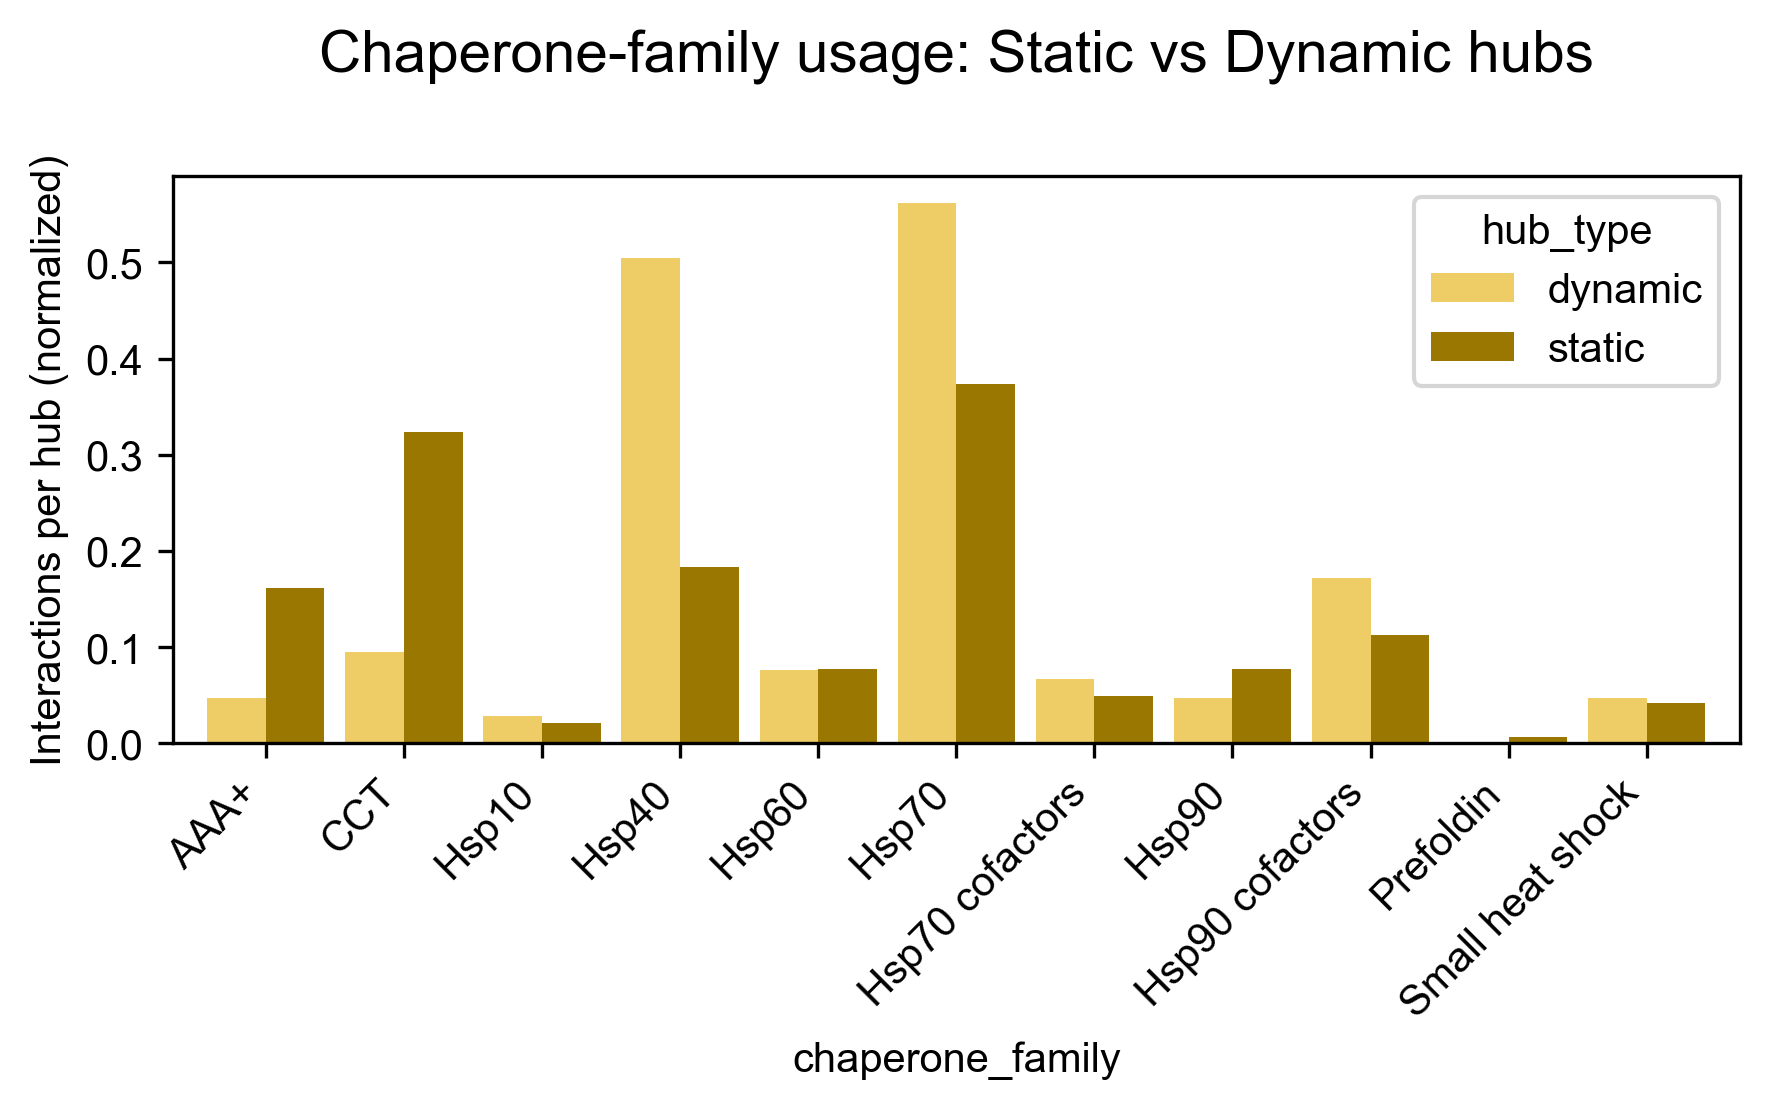

In [47]:
summary = family_counts.pivot(index="chaperone_family",
                              columns="hub_type",
                              values="normalized_frequency").fillna(0)

summary = summary.loc[summary.index]  # keep order

plt.figure(figsize=(6, 3.8))

summary.plot(kind="bar",
             figsize=(6, 3.8),
             color=[MS_COLOR_LIGHT, MS_COLOR_DARK],
             width=0.85)

plt.ylabel("Interactions per hub (normalized)")
plt.title("Chaperone-family usage: Static vs Dynamic hubs")
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [48]:
from statsmodels.stats.multitest import multipletests
from scipy.stats import hypergeom

# --- Parse GO terms from columns ---
# Split semicolon-separated GO IDs
# Just to be safe: replace NaNs with empty strings
final_df["GO_terms"] = final_df["GO_terms"].fillna("")
final_df["GO_terms_human_readable"] = final_df["GO_terms_human_readable"].fillna("")

# Parse GO IDs into a Python list per protein ---
# Example: "GO:0005737;GO:0005937" → ["GO:0005737", "GO:0005937"]
final_df["GO_list"] = final_df["GO_terms"].apply(
    lambda s: [g.strip() for g in s.split(";") if g.strip() != ""]
)

# Parse human-readable mapping GO_ID -> name ---
# Handles formats like:
# "GO:0005737: cytoplasm;GO:0005886: plasma membrane"
def parse_readable_row(s):
    items = [x.strip() for x in s.split(";") if x.strip() != ""]
    mapping = {}
    for it in items:
        if not it.startswith("GO:"):
            continue
        # split only on the first two ":", so we can reconstruct GO:0005737
        parts = it.split(":", 2)  # e.g. ["GO","0005737"," cytoplasm"]
        if len(parts) >= 3:
            go_id = parts[0] + ":" + parts[1]   # "GO:0005737"
            name = parts[2].strip()
            mapping[go_id] = name
        elif len(parts) == 2:
            # case like "GO:0004127" with no name
            go_id = parts[0] + ":" + parts[1]
            mapping.setdefault(go_id, go_id)
    return mapping

final_df["GO_readable_dict"] = final_df["GO_terms_human_readable"].apply(parse_readable_row)

# Global map GO_ID -> name (so we can look up names later)
go_name_map = {}
for d in final_df["GO_readable_dict"]:
    go_name_map.update(d)

print("Example GO mapping (first 10):")
print(list(go_name_map.items())[:10])

Example GO mapping (first 10):
[('GO:0005794', 'Golgi apparatus'), ('GO:0005737', 'cytoplasm'), ('GO:0005937', 'mating projection'), ('GO:0005886', 'plasma membrane'), ('GO:0000753', 'cell morphogenesis involved in conjugation with cellular fusion'), ('GO:0008360', 'regulation of cell shape'), ('GO:0071944', 'cell periphery'), ('GO:0005739', 'mitochondrion'), ('GO:0005524', 'ATP binding'), ('GO:0016887', 'ATP hydrolysis activity')]


In [49]:
# Dynamic hubs with chaperone interactions
dynamic_chap = final_df[
    (final_df["hub_type"] == "dynamic") &
    (final_df["num_chaperone_interactions"] > 0)
].copy()

background = final_df.copy()

print("Dynamic+Chaperone n =", len(dynamic_chap))
all_terms = [t for lst in dynamic_chap["GO_list"] for t in lst]
print("Unique GO terms in Dynamic+Chaperone =", len(set(all_terms)))

go_enrich.sort_values("p_value").head(20)

Dynamic+Chaperone n = 49
Unique GO terms in Dynamic+Chaperone = 227


NameError: name 'go_enrich' is not defined

In [ ]:
# --- 3A. Background GO counts ---
all_go_bg = []
for lst in background["GO_list"]:
    all_go_bg.extend(lst)
background_counts = pd.Series(all_go_bg).value_counts()

# --- 3B. Test GO counts (dynamic + chaperone) ---
all_go_test = []
for lst in dynamic_chap["GO_list"]:
    all_go_test.extend(lst)
test_counts = pd.Series(all_go_test).value_counts()

# We'll only test GO terms that appear at least 2 times in the test set
unique_go_terms = test_counts[test_counts >= 2].index

results = []
N = len(background)        # universe size
n = len(dynamic_chap)      # test set size

for go in unique_go_terms:
    K = background_counts.get(go, 0)   # count in background
    k = test_counts.get(go, 0)         # count in test set
    if K == 0:
        continue

    # hypergeometric P(X >= k)
    pval = hypergeom.sf(k - 1, N, K, n)
    fold = (k / n) / (K / N)

    # human-readable name from global map, fallback to GO ID
    readable = go_name_map.get(go, go)

    results.append([go, readable, k, K, fold, pval])

go_enrich = pd.DataFrame(
    results,
    columns=["GO_ID", "GO_name", "k_test", "K_background", "fold_enrichment", "p_value"]
)

print("Total GO terms tested:", len(go_enrich))

if len(go_enrich) == 0:
    print("No GO terms met the minimum criteria (freq >= 2 in test set).")
else:
    # FDR correction
    go_enrich["FDR"] = multipletests(go_enrich["p_value"], method="fdr_bh")[1]
    # sort by FDR and keep top 15
    go_sig = go_enrich.sort_values("FDR").head(15)
    print(go_sig)


In [ ]:
if len(go_enrich) > 0:

    plot_df = go_enrich.sort_values("FDR").head(15).copy()
    plot_df["neglog10FDR"] = -np.log10(plot_df["FDR"] + 1e-12)

    # Use human-readable name when available, otherwise GO ID
    plot_df["label"] = plot_df.apply(
        lambda r: r["GO_name"] if pd.notna(r["GO_name"]) and r["GO_name"] != "" else r["GO_ID"],
        axis=1
    )

    fig, ax = plt.subplots(figsize=(4, 5))

    scatter = ax.scatter(
        plot_df["fold_enrichment"],
        plot_df["label"],
        s=plot_df["k_test"] * 40,
        c=plot_df["neglog10FDR"],
        cmap="viridis",
        edgecolors="black",
        linewidth=0.6,
    )

    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label("-log10(FDR)", fontsize=10)

    ax.set_xlabel("Fold enrichment", fontsize=11)
    ax.set_ylabel("GO term", fontsize=11)
    ax.set_title("GO Enrichment: Dynamic Hubs + Chaperone", fontsize=12)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.savefig(f"{OUT_PATH}GO_dynamic_chap_dotplot.svg", dpi=300)
    plt.show()


In [ ]:
# Static hubs with ≥1 chaperone interaction
static_chap = final_df[
    (final_df["hub_type"] == "static") &
    (final_df["num_chaperone_interactions"] > 0)
].copy()

background = final_df.copy()

print("Static + Chaperone n =", len(static_chap))


In [ ]:
# --- Background GO counts ---
all_go_bg = []
for lst in background["GO_list"]:
    all_go_bg.extend(lst)
background_counts = pd.Series(all_go_bg).value_counts()

# --- Test GO counts ---
all_go_test = []
for lst in static_chap["GO_list"]:
    all_go_test.extend(lst)
test_counts = pd.Series(all_go_test).value_counts()

# Only GO terms appearing ≥2 times in test set
unique_go_terms = test_counts[test_counts >= 2].index

results = []
N = len(background)
n = len(static_chap)

for go in unique_go_terms:
    K = background_counts.get(go, 0)
    k = test_counts.get(go, 0)

    if K == 0:
        continue

    pval = hypergeom.sf(k - 1, N, K, n)
    fold = (k/n) / (K/N)

    # readable name from go_name_map
    readable = go_name_map.get(go, go)

    results.append([go, readable, k, K, fold, pval])

static_go = pd.DataFrame(
    results,
    columns=["GO_ID", "GO_name", "k_test", "K_background", "fold_enrichment", "p_value"]
)

if len(static_go) == 0:
    print("No GO terms met criteria.")
else:
    static_go["FDR"] = multipletests(static_go["p_value"], method="fdr_bh")[1]
    static_go_sig = static_go.sort_values("FDR").head(15)
    print(static_go_sig)


In [ ]:
if len(static_go) > 0:
    plot_df = static_go.sort_values("FDR").head(15).copy()
    plot_df["neglog10FDR"] = -np.log10(plot_df["FDR"] + 1e-12)

    plot_df["label"] = plot_df.apply(
        lambda r: r["GO_name"] if pd.notna(r["GO_name"]) and r["GO_name"] != "" else r["GO_ID"],
        axis=1
    )

    fig, ax = plt.subplots(figsize=(4, 5))

    scatter = ax.scatter(
        plot_df["fold_enrichment"],
        plot_df["label"],
        s = plot_df["k_test"] * 40,
        c = plot_df["neglog10FDR"],
        cmap="viridis",
        edgecolors="black",
        linewidth=0.6,
    )

    plt.colorbar(scatter, ax=ax).set_label("-log10(FDR)", fontsize=10)

    ax.set_xlabel("Fold enrichment", fontsize=11)
    ax.set_ylabel("GO term", fontsize=11)
    ax.set_title("GO Enrichment: Static Hubs + Chaperone", fontsize=12)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.savefig(f"{OUT_PATH}GO_static_chap.svg", dpi=300)
    plt.show()


In [ ]:
ribosomal_go_ids = set()

for go_id, name in go_name_map.items():
    if name is None:
        continue
    text = name.lower()
    if (
        "ribosom" in text or
        "translation" in text or
        "ribonucleoprotein" in text or
        "r rna" in text or
        "rrna" in text or
        "structural constituent of ribosome" in text
    ):
        ribosomal_go_ids.add(go_id)

print("Identified ribosome-related GO IDs:", len(ribosomal_go_ids))


In [ ]:
def is_ribosomal(go_list):
    return any(go in ribosomal_go_ids for go in go_list)

# Mark ribosomal proteins
final_df["is_ribosomal"] = final_df["GO_list"].apply(is_ribosomal)

print("Total ribosomal proteins:", final_df["is_ribosomal"].sum())


In [ ]:
dynamic_chap_no_ribo = final_df[
    (final_df["hub_type"] == "dynamic") &
    (final_df["num_chaperone_interactions"] > 0) &
    (~final_df["is_ribosomal"])
].copy()

print("Dynamic+Chaperone (NO ribosomal) n =", len(dynamic_chap_no_ribo))


In [ ]:
# --- 3A. Background GO counts ---
all_go_bg = []
for lst in background["GO_list"]:
    all_go_bg.extend(lst)
background_counts = pd.Series(all_go_bg).value_counts()

# --- 3B. Test GO counts (dynamic + chaperone) ---
all_go_test = []
for lst in dynamic_chap_no_ribo["GO_list"]:
    all_go_test.extend(lst)
test_counts = pd.Series(all_go_test).value_counts()

# We'll only test GO terms that appear at least 2 times in the test set
unique_go_terms = test_counts[test_counts >= 2].index

results = []
N = len(background)        # universe size
n = len(dynamic_chap)      # test set size

for go in unique_go_terms:
    K = background_counts.get(go, 0)   # count in background
    k = test_counts.get(go, 0)         # count in test set
    if K == 0:
        continue

    # hypergeometric P(X >= k)
    pval = hypergeom.sf(k - 1, N, K, n)
    fold = (k / n) / (K / N)

    # human-readable name from global map, fallback to GO ID
    readable = go_name_map.get(go, go)

    results.append([go, readable, k, K, fold, pval])

go_enrich = pd.DataFrame(
    results,
    columns=["GO_ID", "GO_name", "k_test", "K_background", "fold_enrichment", "p_value"]
)

print("Total GO terms tested:", len(go_enrich))

if len(go_enrich) == 0:
    print("No GO terms met the minimum criteria (freq >= 2 in test set).")
else:
    # FDR correction
    go_enrich["FDR"] = multipletests(go_enrich["p_value"], method="fdr_bh")[1]
    # sort by FDR and keep top 15
    go_sig = go_enrich.sort_values("FDR").head(15)
    print(go_sig)

In [ ]:
if len(go_enrich) > 0:

    plot_df = go_enrich.sort_values("FDR").head(15).copy()
    plot_df["neglog10FDR"] = -np.log10(plot_df["FDR"] + 1e-12)

    # Use human-readable name when available, otherwise GO ID
    plot_df["label"] = plot_df.apply(
        lambda r: r["GO_name"] if pd.notna(r["GO_name"]) and r["GO_name"] != "" else r["GO_ID"],
        axis=1
    )

    fig, ax = plt.subplots(figsize=(4, 5))

    scatter = ax.scatter(
        plot_df["fold_enrichment"],
        plot_df["label"],
        s=plot_df["k_test"] * 40,
        c=plot_df["neglog10FDR"],
        cmap="viridis",
        edgecolors="black",
        linewidth=0.6,
    )

    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label("-log10(FDR)", fontsize=10)

    ax.set_xlabel("Fold enrichment", fontsize=11)
    ax.set_ylabel("GO term", fontsize=11)
    ax.set_title("GO Enrichment: Dynamic Hubs + Chaperone", fontsize=12)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.savefig(f"{OUT_PATH}GO_dynamic_chap_dotplot.svg", dpi=300)
    plt.show()